
# Task 7 Minimum-Variance Portfolio
### Lena Sophia Bahati
#### Matrikelnummer: 12420656

### Project Setup
Import the required libraries and define global constants used throughout the analysis to ensure consistency across all portfolio construction and evaluation tasks.

In [19]:
import warnings
from plotnine import *
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from pathlib import Path

warnings.filterwarnings(
    "ignore",
     message=".*obj.round has no effect with datetime.*"
)

RISK_FREE_RATE = 0.02
TRADING_DAYS_PER_YEAR = 252
DATE_COLUMN = "Date"

ZERO_RETURN_THRESHOLD = 37

ESTIMATION_WINDOW = 100
EVALUATION_WINDOW = 25
WINDOW_STEP = 25

### Function Definitions
Define the functions that are used throughout the tasks to improve readibility and avoid code duplication.

In [20]:
def iqr_outlier_flags(dataframe):
    """
    Flag observations outside the standard 1.5-IQR interval.

    The function is used for diagnostic outlier checks. It identifies
    unusually large or small return observations for each stock separately,
    without automatically removing them from the dataset.
    """
    q1 = dataframe.quantile(0.25)
    q3 = dataframe.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return dataframe.lt(lower_bound) | dataframe.gt(upper_bound)


def compute_stock_statistics(simple_returns):
    """
    Compute descriptive statistics for each stock.
    
    The statistics summarize the cleaned simple-return dataset and are used
    to check whether the return data are economically plausible before
    estimating the covariance matrix and constructing portfolios.
    """
    stock_statistics = pd.DataFrame(
        {
            "observations": simple_returns.count(),
            "mean_daily_return": simple_returns.mean(),
            "median_daily_return": simple_returns.median(),
            "std_daily_return": simple_returns.std(),
            "annualized_mean_return": (
                simple_returns.mean() * TRADING_DAYS_PER_YEAR
            ),
            "annualized_volatility": (
                simple_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
            ),
            "minimum_daily_return": simple_returns.min(),
            "p01_daily_return": simple_returns.quantile(0.01),
            "p99_daily_return": simple_returns.quantile(0.99),
            "maximum_daily_return": simple_returns.max(),
            "skewness": simple_returns.skew(),
            "excess_kurtosis": simple_returns.kurtosis(),
        }
    )
  
    return stock_statistics.sort_values(
        "annualized_volatility",
        ascending=False,
    )


def compute_gmvp_weights(covariance_matrix):
    """
    Compute global minimum-variance portfolio weights.

    The function implements the analytical MVP solution using the covariance
    matrix and a vector of ones. No short-selling constraint is imposed, 
    so negative weights are possible.
    """
    covariance_array = np.asarray(covariance_matrix)
    number_assets = covariance_array.shape[0]
    ones = np.ones(number_assets)

    solved_system = np.linalg.solve(covariance_array, ones)
    weights = solved_system / (ones @ solved_system)

    return pd.Series(weights, index=covariance_matrix.index)


def portfolio_performance(weights, mean_returns, covariance_matrix):
    """
    Compute annualized portfolio return, volatility, and sharpe ratio.

    The function evaluates a portfolio for given weights, expected returns, and
    covariance matrix. The Sharpe ratio is computed relative to the fixed
    annual risk-free rate used throughout the task.
    """
    weights_array = np.asarray(weights)
    mean_array = np.asarray(mean_returns)
    covariance_array = np.asarray(covariance_matrix)

    port_return = weights_array @ mean_array
    port_variance = weights_array @ covariance_array @ weights_array
    port_volatility = np.sqrt(port_variance)
    port_sharpe = sharpe_ratio(port_return, port_volatility)

    return port_return, port_volatility, port_sharpe


def annualized_return(daily_returns):
    """
    Compute annualized arithmetic return from daily returns.
    """
    return daily_returns.mean() * TRADING_DAYS_PER_YEAR


def annualized_volatility(daily_returns):
    """
    Compute annualized volatility from daily returns.
    """
    return daily_returns.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)


def sharpe_ratio(annual_return, annual_volatility_value):
    """
    Compute the sharpe ratio using a fixed risk-free rate.
    """
    if annual_volatility_value == 0:
        return np.nan
    #if volatility = 0, the function returns NaN to avoid division by zero.

    return (annual_return - RISK_FREE_RATE) / annual_volatility_value


def compute_tangency_weights(mean_returns, covariance_matrix):
    """
    Compute unconstrained tangency portfolio weights.
    
    The tangency portfolio maximizes the Sharpe ratio under the assumptions
    of mean-variance optimization. Short positions are allowed because no
    non-negativity constraint is imposed.
    """
    mean_array = np.asarray(mean_returns)
    covariance_array = np.asarray(covariance_matrix)
    number_assets = covariance_array.shape[0]
    ones = np.ones(number_assets)
    excess_returns = mean_array - RISK_FREE_RATE * ones

    solved_system = np.linalg.solve(covariance_array, excess_returns)
    weights = solved_system / (ones @ solved_system)

    return pd.Series(weights, index=mean_returns.index)


def compute_target_return_weights(
    target_return,
    mean_returns,
    covariance_matrix,
):
    """
    Compute minimum-variance weights for a target return.
    
    The function solves the analytical mean-variance problem with two equality
    constraints: portfolio weights must sum to one and the portfolio must
    reach the specified target return.
    """
    mean_array = np.asarray(mean_returns)
    covariance_array = np.asarray(covariance_matrix)
    number_assets = covariance_array.shape[0]
    ones = np.ones(number_assets)

    inv_cov_ones = np.linalg.solve(covariance_array, ones)
    inv_cov_mu = np.linalg.solve(covariance_array, mean_array)

    a_value = ones @ inv_cov_ones
    b_value = ones @ inv_cov_mu
    c_value = mean_array @ inv_cov_mu
    d_value = a_value * c_value - b_value ** 2

    lambda_value = (c_value - b_value * target_return) / d_value
    gamma_value = (a_value * target_return - b_value) / d_value

    weights = lambda_value * inv_cov_ones + gamma_value * inv_cov_mu

    return pd.Series(weights, index=mean_returns.index)


def compute_efficient_frontier(
    mean_returns,
    covariance_matrix,
    number_points,
    maximum_target_return=None
):
    """
    Compute efficient frontier points over a flexible target-return range.
    
    The optional maximum_target_return allows the plotted frontier to extend
    beyond the highest individual stock return, which is necessary because the
    unconstrained tangency portfolio can have a higher expected return than any
    single stock due to long and short combination.
    """
    if maximum_target_return is None:
        maximum_target_return = mean_returns.max()
    
    target_returns = np.linspace(
        mean_returns.min(),
        maximum_target_return,
        number_points
    )

    frontier_records = []

    for target_return in target_returns:
        weights = compute_target_return_weights(
            target_return,
            mean_returns,
            covariance_matrix
        )
        port_return, port_volatility, port_sharpe = portfolio_performance(
            weights,
            mean_returns,
            covariance_matrix
        )

        frontier_records.append(
            {
                "target_return": target_return,
                "portfolio_return": port_return,
                "portfolio_volatility": port_volatility,
                "portfolio_sharpe": port_sharpe,
            }
        )

    return pd.DataFrame(frontier_records)


def paired_difference_test(
    first_series,
    second_series,
    alternative="two-sided",
):
    """
    Run a paired t-test using first minus second.
    
    The function tests the mean of first_series minus second_series. 
    It is used for the rolling-window comparisons because both strategies
    are evaluated on the same rolling periods.
    """
    difference = first_series - second_series
    difference = difference.dropna()

    sample_size = len(difference)
    mean_difference = difference.mean()
    std_difference = difference.std(ddof=1)
    standard_error = std_difference / np.sqrt(sample_size)
    t_statistic = mean_difference / standard_error
    degrees_freedom = sample_size - 1

    if alternative == "two-sided":
        p_value = 2 * stats.t.sf(abs(t_statistic), degrees_freedom)
    elif alternative == "greater":
        p_value = stats.t.sf(t_statistic, degrees_freedom)
    elif alternative == "less":
        p_value = stats.t.cdf(t_statistic, degrees_freedom)
    else:
        raise ValueError("alternative must be two-sided, greater, or less.")

    return {
        "mean_difference": mean_difference,
        "t_statistic": t_statistic,
        "p_value": p_value,
        "observations": sample_size,
    }


def run_rolling_backtest(simple_returns):
    """
    Run rolling MVP versus naive-portfolio backtest.

    Each window uses 100 daily observations to estimate MVP weights and the
    following 25 trading days for out-of-sample evaluation. The window is then
    shifted forward by 25 trading days, as required in Task 7.6.
    """
    number_assets = simple_returns.shape[1]
    naive_weights = pd.Series(
        np.repeat(1 / number_assets, number_assets),
        index=simple_returns.columns,
    )

    window_records = []
    out_of_sample_daily_records = []

    last_start = (
        len(simple_returns)
        - ESTIMATION_WINDOW
        - EVALUATION_WINDOW
        + 1
    )

    for start_position in range(0, last_start, WINDOW_STEP):
        estimation_slice = slice(
            start_position,
            start_position + ESTIMATION_WINDOW,
        )
        evaluation_slice = slice(
            start_position + ESTIMATION_WINDOW,
            start_position + ESTIMATION_WINDOW + EVALUATION_WINDOW,
        )

        estimation_returns = simple_returns.iloc[estimation_slice]
        evaluation_returns = simple_returns.iloc[evaluation_slice]

        covariance_estimate = (
            estimation_returns.cov() * TRADING_DAYS_PER_YEAR
        )

        mvp_weights = compute_gmvp_weights(covariance_estimate)

        mvp_returns_in = estimation_returns @ mvp_weights
        naive_returns_in = estimation_returns @ naive_weights

        mvp_returns_out = evaluation_returns @ mvp_weights
        naive_returns_out = evaluation_returns @ naive_weights

        mvp_return_in = annualized_return(mvp_returns_in)
        naive_return_in = annualized_return(naive_returns_in)
        mvp_vol_in = annualized_volatility(mvp_returns_in)
        naive_vol_in = annualized_volatility(naive_returns_in)

        mvp_return_out = annualized_return(mvp_returns_out)
        naive_return_out = annualized_return(naive_returns_out)
        mvp_vol_out = annualized_volatility(mvp_returns_out)
        naive_vol_out = annualized_volatility(naive_returns_out)

        window_records.append(
            {
                "window": len(window_records) + 1,
                "estimation_start": estimation_returns.index.min(),
                "estimation_end": estimation_returns.index.max(),
                "evaluation_start": evaluation_returns.index.min(),
                "evaluation_end": evaluation_returns.index.max(),
                "mvp_return_in": mvp_return_in,
                "mvp_vol_in": mvp_vol_in,
                "mvp_sharpe_in": sharpe_ratio(
                    mvp_return_in,
                    mvp_vol_in,
                ),
                "naive_return_in": naive_return_in,
                "naive_vol_in": naive_vol_in,
                "naive_sharpe_in": sharpe_ratio(
                    naive_return_in,
                    naive_vol_in,
                ),
                "mvp_return_out": mvp_return_out,
                "mvp_vol_out": mvp_vol_out,
                "mvp_sharpe_out": sharpe_ratio(
                    mvp_return_out,
                    mvp_vol_out,
                ),
                "naive_return_out": naive_return_out,
                "naive_vol_out": naive_vol_out,
                "naive_sharpe_out": sharpe_ratio(
                    naive_return_out,
                    naive_vol_out,
                ),
            }
        )

        out_of_sample_daily_records.append(
            pd.DataFrame(
                {
                    "mvp_daily_return": mvp_returns_out,
                    "naive_daily_return": naive_returns_out,
                },
                index=evaluation_returns.index,
            )
        )

    backtest_results = pd.DataFrame(window_records)
    out_of_sample_daily_returns = pd.concat(out_of_sample_daily_records)

    return backtest_results, out_of_sample_daily_returns

## Task 7.1 Data Cleaning and Return Construction
The purpose of this task is to prepare the stock return dataset for the portfolio analysis.  
The dataset is inspected for missing values, non-numeric entries, duplicate dates, non-positive index levels, closure-like trading days, and extreme observations.  
Any unusual or unreasonable observations are identified for later adjustment.  
Log returns are used for diagnostic checks, especially for identifying unusual return observations.  
For covariance estimation, portfolio construction, and the rolling backtest, simple returns are used because portfolio returns are weighted sums of simple asset returns.  
Basic descriptive statistics and visualizations should demonstrate that the cleaned dataset is economically plausible and suitable for the subsequetent tasks.


TASK 7.1: BASIC DATA OVERVIEW
Number of dates: 1304
Number of stocks: 40
Start date: 2021-01-01
End date: 2025-12-31


,Date,ADIDAS - TOT RETURN IND,AIRBUS - TOT RETURN IND,ALLIANZ - TOT RETURN IND,BASF - TOT RETURN IND,BAYER - TOT RETURN IND,BEIERSDORF - TOT RETURN IND,BMW - TOT RETURN IND,BRENNTAG - TOT RETURN IND,COMMERZBANK - TOT RETURN IND,...,RWE - TOT RETURN IND,SAP - TOT RETURN IND,SCOUT24 - TOT RETURN IND,SIEMENS - TOT RETURN IND,SIEMENS ENERGY N - TOT RETURN IND,SIEMENS HEALTHINEERS - TOT RETURN IND,SYMRISE - TOT RETURN IND,VOLKSWAGEN PREF. - TOT RETURN IND,VONOVIA - TOT RETURN IND,ZALANDO - TOT RETURN IND
0,2021-01-01,4124.59,760.55,8424.11,11792.89,4933.93,12311.19,16837.64,470.15,36.14,...,3792.80,30074.14,229.98,6196.29,141.76,157.31,835.99,1655.24,456.22,423.63
1,2021-01-04,4050.25,761.48,8296.30,11796.54,5032.18,12383.88,16585.37,469.13,35.70,...,3917.87,29587.71,227.94,6187.88,141.06,159.13,840.19,1625.30,450.87,435.35
2,2021-01-05,3984.16,760.97,8174.73,11756.42,5079.53,12202.15,16423.36,470.30,36.50,...,3850.95,29386.44,227.94,6186.82,140.78,160.17,830.64,1618.52,456.83,451.16
3,2021-01-06,4029.59,763.85,8594.79,12327.20,5272.97,12168.40,16522.88,475.54,38.70,...,3986.99,29593.31,220.79,6394.00,143.07,164.05,821.47,1625.73,440.03,447.63
4,2021-01-07,3980.04,759.19,8549.00,12447.55,5423.66,12119.07,16495.10,496.67,38.51,...,4068.18,29447.94,220.11,6496.01,149.81,163.79,809.24,1620.05,437.59,449.49


,Date,ADIDAS - TOT RETURN IND,AIRBUS - TOT RETURN IND,ALLIANZ - TOT RETURN IND,BASF - TOT RETURN IND,BAYER - TOT RETURN IND,BEIERSDORF - TOT RETURN IND,BMW - TOT RETURN IND,BRENNTAG - TOT RETURN IND,COMMERZBANK - TOT RETURN IND,...,RWE - TOT RETURN IND,SAP - TOT RETURN IND,SCOUT24 - TOT RETURN IND,SIEMENS - TOT RETURN IND,SIEMENS ENERGY N - TOT RETURN IND,SIEMENS HEALTHINEERS - TOT RETURN IND,SYMRISE - TOT RETURN IND,VOLKSWAGEN PREF. - TOT RETURN IND,VONOVIA - TOT RETURN IND,ZALANDO - TOT RETURN IND
1299,2025-12-25,2368.88,1745.33,20723.51,10809.91,4116.16,12532.34,28793.41,410.13,261.89,...,5610.17,62892.59,315.21,14263.36,566.35,179.39,551.69,1738.55,238.83,116.60
1300,2025-12-26,2368.88,1745.40,20723.51,10809.91,4116.16,12532.34,28793.41,410.13,261.89,...,5610.17,62892.59,315.21,14263.36,566.35,179.39,551.69,1738.55,238.83,116.60
1301,2025-12-29,2426.48,1745.82,20628.21,10933.74,4184.45,12559.28,28929.84,413.96,261.01,...,5625.21,63302.06,313.37,14251.34,567.29,180.60,553.62,1725.98,241.31,117.12
1302,2025-12-30,2438.72,1772.08,20707.63,11022.89,4244.70,12545.81,28936.05,409.97,264.90,...,5662.82,63362.72,314.29,14350.49,564.47,180.56,551.37,1740.23,242.69,116.74
1303,2025-12-31,2438.72,1767.33,20707.63,11022.89,4244.70,12545.81,28936.05,409.97,264.90,...,5662.82,63362.72,314.29,14350.49,564.47,180.56,551.37,1740.23,242.69,116.74


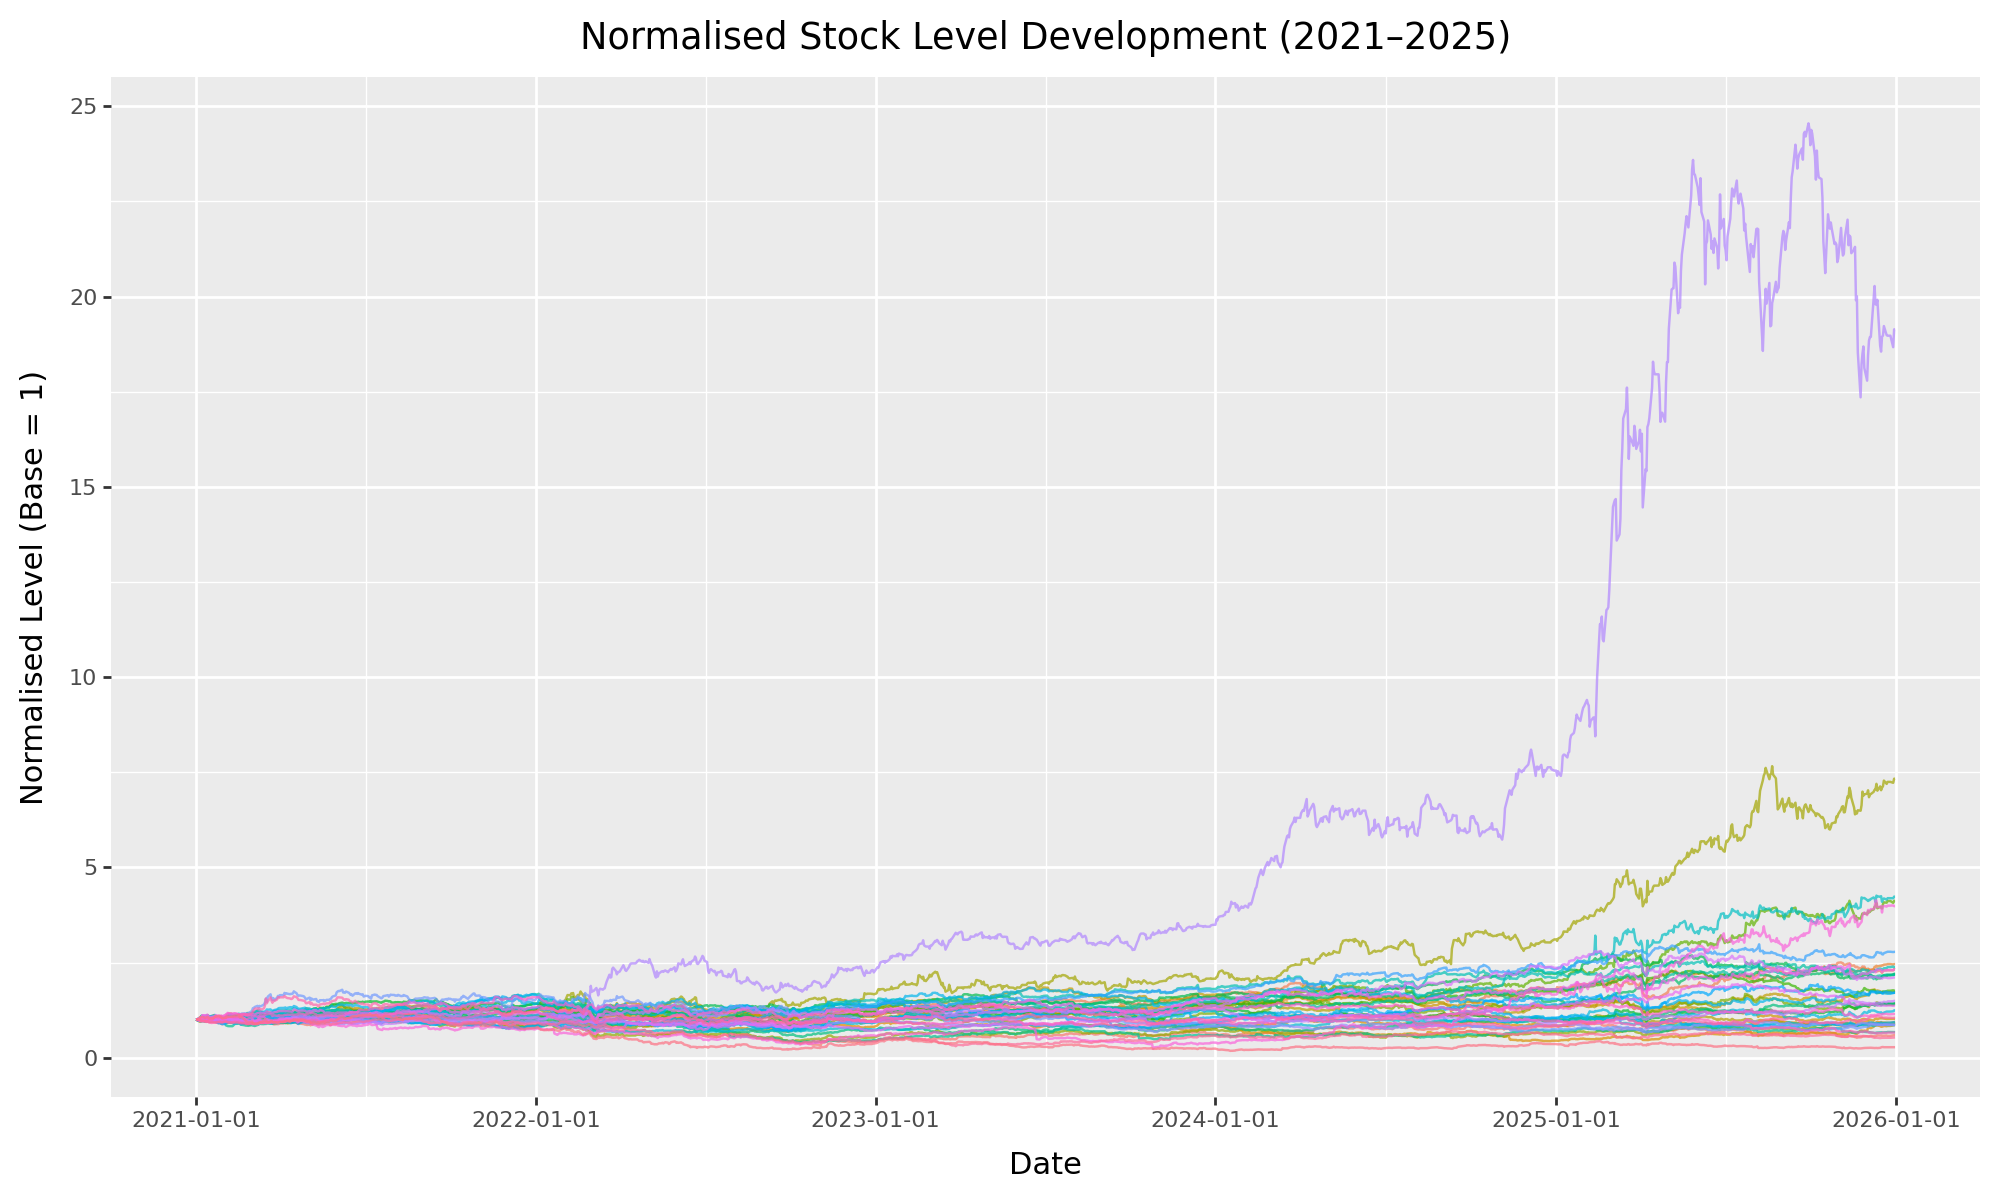

In [21]:
# Load data, convert types, and present a basic overview

DATA_PATH = Path("equity_data.xlsx")

equity_raw = pd.read_excel(DATA_PATH)
equity_raw = equity_raw.replace("NA", np.nan)

equity_raw.columns = (
    equity_raw.columns
    .astype(str)
    .str.strip()
)

if pd.api.types.is_numeric_dtype(equity_raw[DATE_COLUMN]):
    equity_raw[DATE_COLUMN] = pd.to_datetime(
        equity_raw[DATE_COLUMN],
        origin="1899-12-30",
        unit="D",
        errors="coerce",
    )
else:
    equity_raw[DATE_COLUMN] = pd.to_datetime(
        equity_raw[DATE_COLUMN],
        errors="coerce",
    )

asset_columns = equity_raw.columns.drop(DATE_COLUMN)

equity_raw[asset_columns] = equity_raw[asset_columns].apply(
    pd.to_numeric,
    errors="coerce",
)

equity_raw = (
    equity_raw
    .sort_values(DATE_COLUMN)
    .reset_index(drop=True)
)

equity_levels_raw = equity_raw.set_index(DATE_COLUMN)

print("\nTASK 7.1: BASIC DATA OVERVIEW")
print(f"Number of dates: {equity_levels_raw.shape[0]}")
print(f"Number of stocks: {equity_levels_raw.shape[1]}")
print(f"Start date: {equity_levels_raw.index.min().date()}")
print(f"End date: {equity_levels_raw.index.max().date()}")

display(equity_raw.head())
display(equity_raw.tail())

equity_levels_raw.index = pd.to_datetime(equity_levels_raw.index)
equity_levels_normalised = equity_levels_raw.divide(
    equity_levels_raw.apply(lambda column: column.dropna().iloc[0])
)

stock_level_plot_data_reset = (
    equity_levels_normalised
    .reset_index()
    .melt(
        id_vars=DATE_COLUMN,
        var_name="stock",
        value_name="stock_level"
    )
)

stock_level_plot = (
    ggplot(
        stock_level_plot_data_reset,
        aes(
            x=DATE_COLUMN,
            y="stock_level",
            color="stock",
            group="stock"
        )
    )
    + geom_line(size=0.5, alpha=0.7, show_legend=False)  
    + labs(
        title="Normalised Stock Level Development (2021–2025)",
        x="Date",
        y="Normalised Level (Base = 1)"
    )
    + theme(
        figure_size=(10, 6),
        axis_text_x=element_text(size=8),
        axis_text_y=element_text(size=8)
    )
)

stock_level_plot.show()

Interpretation:  
The dataset contains 40 stocks with observations from January 2021 to December 2025.  
Preliminary inspection confirms that all data are numeric and correctly formatted.  
The normalized stock level plot shows that most stocks move in a relatively tight band, reflecting general market trends.  
A few stocks exhibit extreme growth, which is visually distinguishable without distorting the overall dataset dynamics.

In [22]:
# Control for missing or unreasonable observations

weekday_index = pd.bdate_range(
    start=equity_levels_raw.index.min(),
    end=equity_levels_raw.index.max(),
)

missing_weekdays = weekday_index.difference(equity_levels_raw.index)
extra_dates = equity_levels_raw.index.difference(weekday_index)

duplicate_date_count = int(equity_levels_raw.index.duplicated().sum())

weekend_date_count = int((equity_levels_raw.index.weekday >= 5).sum())

total_missing_values = int(equity_levels_raw.isna().sum().sum())

non_positive_values = int((equity_levels_raw <= 0).sum().sum())


quality_summary = pd.DataFrame(
    {
        "metric": [
            "Number of dates",
            "Number of stocks",
            "Start date",
            "End date",
            "Duplicate dates",
            "Weekend dates",
            "Missing weekdays",
            "Extra non-weekday dates",
            "Missing index values",
            "Non-positive index values",
        ],
        "value": [
            equity_levels_raw.shape[0],
            equity_levels_raw.shape[1],
            equity_levels_raw.index.min().date(),
            equity_levels_raw.index.max().date(),
            duplicate_date_count,
            weekend_date_count,
            len(missing_weekdays),
            len(extra_dates),
            total_missing_values,
            non_positive_values,
        ],
    }
)

print("\nTASK 7.1: QUALITY SUMMARY")
display(quality_summary)

# Investigate the missing values

missing_details = []

for asset in asset_columns:
    missing_mask = equity_levels_raw[asset].isna()
    

    if missing_mask.any():
        missing_index = equity_levels_raw.index[missing_mask]

        missing_details.append(
            {
                "asset": asset,
                "missing_values": int(missing_mask.sum()),
                "first_missing_date": missing_index.min().date(),
                "last_missing_date": missing_index.max().date(),
                "first_valid_date": (
                    equity_levels_raw[asset]
                    .first_valid_index()
                    .date()
                ),
                "first_valid_value": (
                    equity_levels_raw[asset]
                    .dropna()
                    .iloc[0]
                ),
            }
        )
# create a dictionary with missing values of stocks and sets the first valid valid after the first non-missing value

missing_summary = pd.DataFrame(missing_details)

print("\nTASK 7.1: MISSING VALUE SUMMARY")
display(missing_summary)



TASK 7.1: QUALITY SUMMARY


,metric,value
0,Number of dates,1304
1,Number of stocks,40
2,Start date,2021-01-01
3,End date,2025-12-31
4,Duplicate dates,0
5,Weekend dates,0
6,Missing weekdays,0
7,Extra non-weekday dates,0
8,Missing index values,245
9,Non-positive index values,0



TASK 7.1: MISSING VALUE SUMMARY


,asset,missing_values,first_missing_date,last_missing_date,first_valid_date,first_valid_value
0,DAIMLER TRUCK HOLDING E - TOT RETURN IND,245,2021-01-01,2021-12-09,2021-12-10,100.0


No critical data issues in form of unreasonable observations are detected.  
245 observations for the Daimler Truck Holdings Stock are missing.   
All of these are in the year 2021. The first valid date is December 10, 2021.

In [23]:
# Initial log returns and returns after removing closure like days
 
log_returns_all_weekdays = np.log(equity_levels_raw).diff()

zero_return_counts = (
    log_returns_all_weekdays
    .abs()
    .le(1e-12)
    .sum(axis=1)
)

zero_count_distribution = (
    zero_return_counts
    .value_counts()
    .sort_index()
    .rename_axis("number_of_stocks_with_zero_return")
    .reset_index(name="number_of_dates")
)

print("\nTASK 7.1: ZERO RETURN DISTRIBUTION")
display(zero_count_distribution)


closure_like_dates = zero_return_counts[
    zero_return_counts >= ZERO_RETURN_THRESHOLD
].index

closure_like_summary = pd.DataFrame(
    {
        "date": closure_like_dates,
        "stocks_with_zero_return": (
            zero_return_counts.loc[closure_like_dates].values
        ),
    }
)
closure_like_summary.index = range(1, len(closure_like_summary) + 1)
print("\nTASK 7.1: CLOSURE-LIKE WEEKDAYS REMOVED")
display(closure_like_summary)

equity_levels_no_closure = equity_levels_raw.drop(
    index=closure_like_dates,
).copy()

log_returns_precheck = np.log(equity_levels_no_closure).diff()

# Interquartile range

iqr_flags = iqr_outlier_flags(log_returns_precheck)

iqr_outlier_counts = (
    iqr_flags
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="number_of_iqr_flags")
)

print("\nTASK 7.1: IQR OUTLIER COUNTS")
display(iqr_outlier_counts.head(10))

simple_returns_for_task_7 = (
    equity_levels_no_closure
    .pct_change()
    .dropna(axis=0, how="any") 
    # keep only rows where all stocks have valid returns
)

# Final log return matrix

log_returns_for_task_7 = (
    np.log(equity_levels_no_closure)
    .diff()
    .dropna(axis=0, how="any")
)


print("\nTASK 7.1: FINAL CLEAN RETURN DATASET")
print(f"Return observations: {simple_returns_for_task_7.shape[0]}")
print(f"Number of stocks: {simple_returns_for_task_7.shape[1]}")
print(f"First return date: {simple_returns_for_task_7.index.min().date()}")
print(f"Last return date: {simple_returns_for_task_7.index.max().date()}")
print(
    "Missing return values:",
    int(simple_returns_for_task_7.isna().sum().sum()),
)


TASK 7.1: ZERO RETURN DISTRIBUTION


,number_of_stocks_with_zero_return,number_of_dates
0,0,851
1,1,332
2,2,79
3,3,11
4,4,2
5,37,1
6,38,16
7,39,12



TASK 7.1: CLOSURE-LIKE WEEKDAYS REMOVED


,date,stocks_with_zero_return
1,2021-04-02,39
2,2021-04-05,38
3,2021-05-24,37
4,2021-12-24,39
5,2021-12-31,38
6,2022-04-15,39
7,2022-04-18,38
8,2022-12-26,39
9,2023-04-07,39
10,2023-04-10,38



TASK 7.1: IQR OUTLIER COUNTS


,number_of_iqr_flags
FRESENIUS MED.CARE - TOT RETURN IND,78
BRENNTAG - TOT RETURN IND,75
MTU AERO ENGINES HLDG. - TOT RETURN IND,70
VONOVIA - TOT RETURN IND,69
RHEINMETALL - TOT RETURN IND,68
AIRBUS - TOT RETURN IND,68
HANNOVER RUECK - TOT RETURN IND,65
COMMERZBANK - TOT RETURN IND,64
SCOUT24 - TOT RETURN IND,59
DEUTSCHE BANK - TOT RETURN IND,59



TASK 7.1: FINAL CLEAN RETURN DATASET
Return observations: 1032
Number of stocks: 40
First return date: 2021-12-13
Last return date: 2025-12-30
Missing return values: 0


Several days show very low or zero returns for many stocks simultaneously.  
These “closure-like” days (≥37 of 40 stocks with zero return) are removed to avoid biasing volatility and correlations.  

Because Daimler Truck has no valid observations before December 10, 2021, the portfolio analysis uses a common sample from December 13, 2021 to December 30, 2025.  
This ensures that all 40 stocks are analyzed over the same time period and avoids having to estimate missing values.

After cleaning, the final simple return dataset has 1,032 observations across 40 stocks, with no missing values.  
The IQR outlier check shows that some stocks have more extreme returns than others. Fresenius Med. Care has the highest number of flagged outliers (78 days).  
These outliers are unusual but not necessarily errors. They likely actual market movements rather than data errors.

In [24]:
# Descriptive statistics for the stocks

stock_statistics = compute_stock_statistics(simple_returns_for_task_7)

print("\nTASK 7.1: STOCK-LEVEL DESCRIPTIVE STATISTICS")
display(stock_statistics.round(4))

all_clean_returns = simple_returns_for_task_7.stack()

panel_summary = all_clean_returns.describe(
   percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
).to_frame(name="all_clean_daily_returns")

print("\nTASK 7.1: OVERALL RETURN DISTRIBUTION")
display(panel_summary.round(4))

volatility_summary = (
    stock_statistics["annualized_volatility"]
    .describe()
    .to_frame(name="annualized_volatility")
)

print("\nTASK 7.1: ANNUALIZED VOLATILITY SUMMARY")
display(volatility_summary.round(4))

extreme_return_table = (
    simple_returns_for_task_7
    .abs()
    .stack()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

extreme_return_table.columns = [
    "date",
    "stock",
    "absolute_simple_return",
]

extreme_return_table["absolute_simple_return_percent"] = (
    100 * extreme_return_table["absolute_simple_return"]
)

print("\nTASK 7.1: LARGEST REMAINING DAILY RETURNS")
display(extreme_return_table.round(4))


TASK 7.1: STOCK-LEVEL DESCRIPTIVE STATISTICS


,observations,mean_daily_return,median_daily_return,std_daily_return,annualized_mean_return,annualized_volatility,minimum_daily_return,p01_daily_return,p99_daily_return,maximum_daily_return,skewness,excess_kurtosis
SIEMENS ENERGY N - TOT RETURN IND,1032,0.0021,0.0017,0.0314,0.5384,0.4990,-0.3381,-0.0656,0.0825,0.1748,-1.5924,19.9670
ZALANDO - TOT RETURN IND,1032,-0.0006,-0.0021,0.0307,-0.1481,0.4880,-0.1410,-0.0757,0.0802,0.1926,0.3750,3.1989
RHEINMETALL - TOT RETURN IND,1032,0.0033,0.0026,0.0282,0.8317,0.4484,-0.1181,-0.0696,0.0802,0.2909,1.1873,12.7252
COMMERZBANK - TOT RETURN IND,1032,0.0021,0.0021,0.0256,0.5192,0.4060,-0.1133,-0.0665,0.0730,0.1659,0.2166,4.2595
INFINEON TECHNOLOGIES - TOT RETURN IND,1032,0.0003,0.0001,0.0242,0.0660,0.3844,-0.0853,-0.0577,0.0666,0.1501,0.4421,2.9295
CONTINENTAL - TOT RETURN IND,1032,0.0003,-0.0003,0.0232,0.0836,0.3676,-0.1064,-0.0605,0.0663,0.1109,0.1410,2.7880
ADIDAS - TOT RETURN IND,1032,-0.0001,-0.0004,0.0225,-0.0282,0.3571,-0.1166,-0.0557,0.0584,0.2146,0.8092,11.1535
DEUTSCHE BANK - TOT RETURN IND,1032,0.0014,0.0017,0.0224,0.3617,0.3561,-0.1139,-0.0684,0.0644,0.1182,-0.1915,4.7090
VONOVIA - TOT RETURN IND,1032,-0.0003,-0.0007,0.0211,-0.0791,0.3349,-0.0850,-0.0564,0.0625,0.0765,0.1638,1.5923
BAYER - TOT RETURN IND,1032,0.0001,0.0003,0.0209,0.0180,0.3324,-0.1765,-0.0613,0.0530,0.1306,-0.7401,10.2839



TASK 7.1: OVERALL RETURN DISTRIBUTION


,all_clean_daily_returns
count,41280.0000
mean,0.0005
std,0.0191
min,-0.3381
1%,-0.0520
5%,-0.0285
25%,-0.0088
50%,0.0005
75%,0.0098
95%,0.0292



TASK 7.1: ANNUALIZED VOLATILITY SUMMARY


,annualized_volatility
count,40.0000
mean,0.2931
std,0.0760
min,0.1853
25%,0.2460
50%,0.2773
75%,0.3313
max,0.4990



TASK 7.1: LARGEST REMAINING DAILY RETURNS


,date,stock,absolute_simple_return,absolute_simple_return_percent
0,2023-10-26,SIEMENS ENERGY N - TOT RETURN IND,0.3381,33.8062
1,2022-02-28,RHEINMETALL - TOT RETURN IND,0.2909,29.0918
2,2023-06-23,SIEMENS ENERGY N - TOT RETURN IND,0.2622,26.2216
3,2022-11-04,ADIDAS - TOT RETURN IND,0.2146,21.4643
4,2024-03-13,ZALANDO - TOT RETURN IND,0.1926,19.2584
5,2025-02-12,HEIDELBERG MATERIALS - TOT RETURN IND,0.1811,18.1072
6,2023-10-11,FRESENIUS MED.CARE - TOT RETURN IND,0.1784,17.8360
7,2023-11-20,BAYER - TOT RETURN IND,0.1765,17.6520
8,2025-04-09,SIEMENS ENERGY N - TOT RETURN IND,0.1748,17.4778
9,2024-09-11,COMMERZBANK - TOT RETURN IND,0.1659,16.5935


The descriptive statistics indicate that the cleaned dataset is economically plausible.  
The cleaned return dataset contains 1,032 daily observations for 40 stocks.  
Daily returns are centered close to zero, with the mean return of 0.05% and a median return of 0.05%.  
The average annualized volatility across all stocks is 29.31%, although voaltility differs substantially between companies.  
This likely reflects different risk profiles within the DAX 40.  
Several large daily return movements remain in the dataset, with the largest absolute return reaching 33.81%.  
These observations are retained because they are likely related to market events rather than data errors.

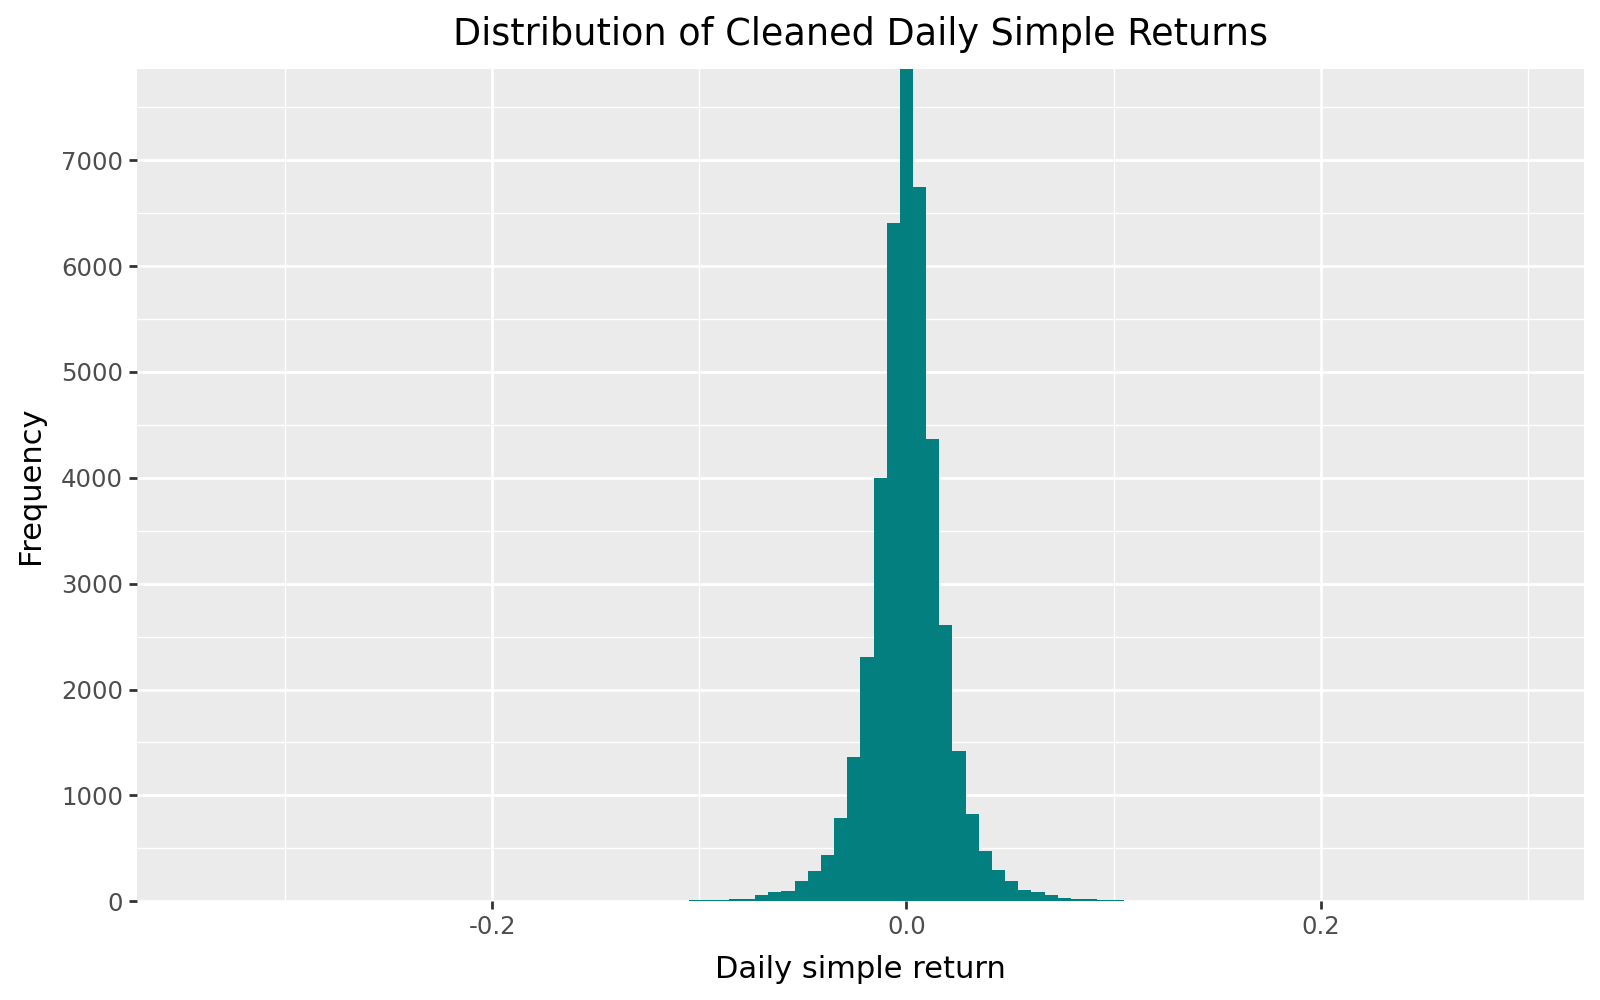

In [25]:
# Return distribution 

return_distribution_plot_data = (
    all_clean_returns
    .reset_index()
)

return_distribution_plot_data.columns = [
    "date",
    "stock",
    "daily_simple_return"
]

# the distribution of all cleaned daily stock returns is visualized to identify
# concentration around the mean as well as the presence of extreme observations
returns_distribution_plot = (
    ggplot(
        return_distribution_plot_data,
        aes(x="daily_simple_return"),
    )
    + geom_histogram(
        bins=100,
        fill="#037F7F"
    ) 
    + labs(
        title="Distribution of Cleaned Daily Simple Returns",
        x="Daily simple return",
        y="Frequency"
    )+ scale_y_continuous(
        limits=(0, None),
         breaks=np.linspace(0, 8000, 9),
        expand=(0, 0)
    )
    + theme(figure_size=(8,5))
)
returns_distribution_plot.show()

Most daily stock returns are concentrated around zero and the highest frequency is close to the center of the distribution.  
This is consistent with the descriptive statistics, which indicated a mean and median return close to zero.  
The distribution is approximately bell-shaped, but exhibits noticeable tails on both sides. This suggests that large positive and negative return movements occur more frequently than would be expected under a perfectly normal distribution.   
Such behaviour is typical for financial return series and reflects the impact of market news, macroeconomic events, and periods of elevated uncertainty.  
Overall, the histogramm supports the conclusion that the cleaned dataset exhibits realistic characteristics commonly observed in equity markets.

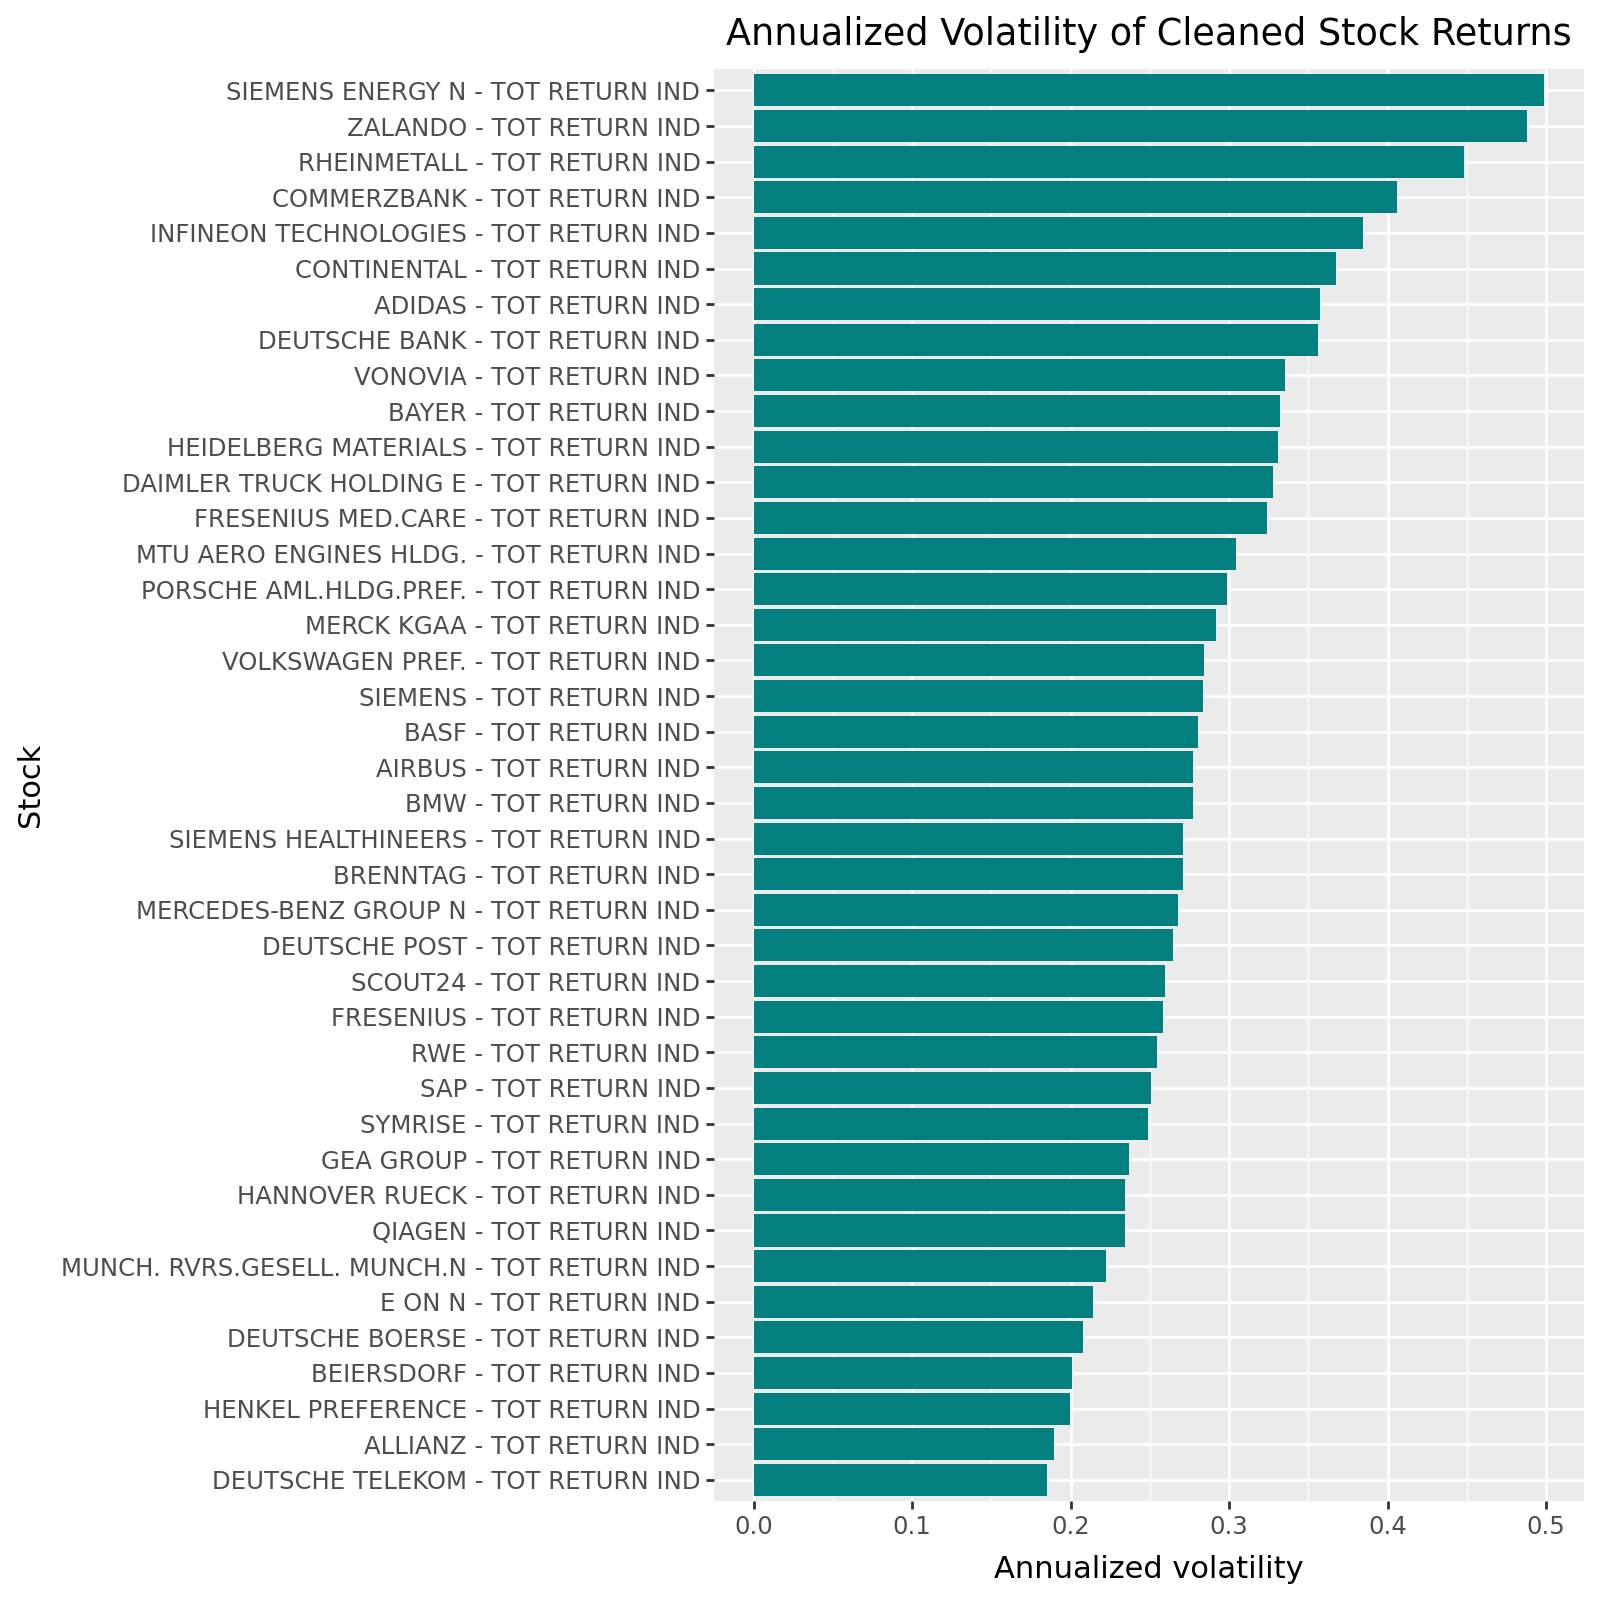

In [26]:
# Volatility comparison across stocks

volatility_plot_data = (
    stock_statistics["annualized_volatility"]
    .sort_values()
    .reset_index()
)

volatility_plot_data.columns = [
    "stock", 
    "annualized_volatility"]

volatility_plot_data["stock"] = pd.Categorical(
    volatility_plot_data["stock"],
    categories=volatility_plot_data["stock"],
    ordered=True,
)
# annualized volatility of each stock is visualized 
# to examine how risk differs across companies
volatility_plot = (
    ggplot(
        volatility_plot_data, 
        aes(x="stock", 
            y="annualized_volatility")
    )
    + geom_col(fill="#037F7F")
    + coord_flip()
    + labs(
        title="Annualized Volatility of Cleaned Stock Returns",
        x="Stock",
        y="Annualized volatility"
    ) 
    + theme(figure_size=(8, 8))
)
volatility_plot.show()

There are substantial differences in risk across the 40 stocks. Annualized volatility ranges from approximately 18% for the least volatile stocks to around 50% for the most volatile stocks.
The most volatile stocks include Siemens Energy, Zalando, and Rheinmetall, which indicates that these companies experienced particularly large price fluctuations during the sample period.  
In contrast, Deutsche Telekom, Allianz, and Henke have comparatively lower volatility and therefore more stable return behaviour.  
These differences are economically plausible because firms that operate in different industries and are exposed to different sources of risk.   
Technology, defence, banking, and cyclical firms generally tend to experience larger fluctuations than mature telecommunications or consumer goods companies.  
The presence of substantial volatility differences is important for the subsequent portfolio optimization tasks because the covariance matrix and portfolio weights depend directly on these risk characteristics.

## Task 7.2 Variance-Covariance Matrix Estimation
This task focuses on the estimation of the variance-covariance matrix Σ from the cleaned stock return data.  
The covariance matrix captures both the individual variances of the stocks (diagonal elements) and their co-movements (off-diagonal elements).  
The matrix is the central input for the global minimum-variance portfolio in the following tasks.

In [27]:
# Estimate the variance-covariance matrix

mean_returns_annual = (
    simple_returns_for_task_7.mean()
    * TRADING_DAYS_PER_YEAR
)

covariance_matrix_daily = simple_returns_for_task_7.cov()
covariance_matrix_annual = (
    covariance_matrix_daily
    * TRADING_DAYS_PER_YEAR
)

correlation_matrix = simple_returns_for_task_7.corr()

print("\nTASK 7.2: DAILY COVARIANCE MATRIX")
display(covariance_matrix_daily.round(6))

print("\nTASK 7.2: ANNUALIZED COVARIANCE MATRIX")
display(covariance_matrix_annual.round(6))

covariance_checks = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Columns",
            "Missing covariance values",
            "Infinite covariance values",
            "Smallest variance",
            "Largest variance",
        ],
        "value": [
            covariance_matrix_annual.shape[0],
            covariance_matrix_annual.shape[1],
            int(covariance_matrix_annual.isna().sum().sum()),
            int(np.isinf(covariance_matrix_annual).sum().sum()),
            covariance_matrix_annual.values.diagonal().min(),
            covariance_matrix_annual.values.diagonal().max(),
        ],
    }
)

print("\nTASK 7.2: COVARIANCE MATRIX CHECKS")
display(covariance_checks.round(4))


TASK 7.2: DAILY COVARIANCE MATRIX


,ADIDAS - TOT RETURN IND,AIRBUS - TOT RETURN IND,ALLIANZ - TOT RETURN IND,BASF - TOT RETURN IND,BAYER - TOT RETURN IND,BEIERSDORF - TOT RETURN IND,BMW - TOT RETURN IND,BRENNTAG - TOT RETURN IND,COMMERZBANK - TOT RETURN IND,CONTINENTAL - TOT RETURN IND,...,RWE - TOT RETURN IND,SAP - TOT RETURN IND,SCOUT24 - TOT RETURN IND,SIEMENS - TOT RETURN IND,SIEMENS ENERGY N - TOT RETURN IND,SIEMENS HEALTHINEERS - TOT RETURN IND,SYMRISE - TOT RETURN IND,VOLKSWAGEN PREF. - TOT RETURN IND,VONOVIA - TOT RETURN IND,ZALANDO - TOT RETURN IND
ADIDAS - TOT RETURN IND,0.000506,0.000124,0.000103,0.000179,0.000095,0.000065,0.000161,0.000106,0.000175,0.000219,...,0.000069,0.000136,0.000061,0.000196,0.000186,0.000143,0.000100,0.000178,0.000137,0.000305
AIRBUS - TOT RETURN IND,0.000124,0.000306,0.000093,0.000103,0.000072,0.000034,0.000095,0.000083,0.000156,0.000139,...,0.000057,0.000085,0.000049,0.000149,0.000130,0.000073,0.000039,0.000103,0.000075,0.000136
ALLIANZ - TOT RETURN IND,0.000103,0.000093,0.000143,0.000108,0.000072,0.000035,0.000086,0.000060,0.000154,0.000111,...,0.000057,0.000071,0.000020,0.000115,0.000111,0.000057,0.000039,0.000101,0.000068,0.000127
BASF - TOT RETURN IND,0.000179,0.000103,0.000108,0.000312,0.000129,0.000034,0.000176,0.000113,0.000205,0.000223,...,0.000060,0.000077,0.000022,0.000175,0.000157,0.000104,0.000055,0.000189,0.000094,0.000219
BAYER - TOT RETURN IND,0.000095,0.000072,0.000072,0.000129,0.000438,0.000043,0.000103,0.000088,0.000120,0.000125,...,0.000062,0.000044,0.000031,0.000109,0.000095,0.000060,0.000047,0.000116,0.000073,0.000135
BEIERSDORF - TOT RETURN IND,0.000065,0.000034,0.000035,0.000034,0.000043,0.000160,0.000041,0.000038,0.000046,0.000039,...,0.000024,0.000039,0.000028,0.000055,0.000028,0.000051,0.000055,0.000039,0.000021,0.000058
BMW - TOT RETURN IND,0.000161,0.000095,0.000086,0.000176,0.000103,0.000041,0.000305,0.000101,0.000188,0.000233,...,0.000061,0.000078,0.000025,0.000162,0.000135,0.000083,0.000040,0.000219,0.000073,0.000178
BRENNTAG - TOT RETURN IND,0.000106,0.000083,0.000060,0.000113,0.000088,0.000038,0.000101,0.000292,0.000104,0.000136,...,0.000037,0.000053,0.000043,0.000109,0.000093,0.000087,0.000061,0.000101,0.000060,0.000133
COMMERZBANK - TOT RETURN IND,0.000175,0.000156,0.000154,0.000205,0.000120,0.000046,0.000188,0.000104,0.000654,0.000230,...,0.000078,0.000106,0.000026,0.000205,0.000227,0.000077,0.000025,0.000216,0.000067,0.000222
CONTINENTAL - TOT RETURN IND,0.000219,0.000139,0.000111,0.000223,0.000125,0.000039,0.000233,0.000136,0.000230,0.000536,...,0.000087,0.000100,0.000042,0.000202,0.000191,0.000110,0.000052,0.000234,0.000117,0.000279



TASK 7.2: ANNUALIZED COVARIANCE MATRIX


,ADIDAS - TOT RETURN IND,AIRBUS - TOT RETURN IND,ALLIANZ - TOT RETURN IND,BASF - TOT RETURN IND,BAYER - TOT RETURN IND,BEIERSDORF - TOT RETURN IND,BMW - TOT RETURN IND,BRENNTAG - TOT RETURN IND,COMMERZBANK - TOT RETURN IND,CONTINENTAL - TOT RETURN IND,...,RWE - TOT RETURN IND,SAP - TOT RETURN IND,SCOUT24 - TOT RETURN IND,SIEMENS - TOT RETURN IND,SIEMENS ENERGY N - TOT RETURN IND,SIEMENS HEALTHINEERS - TOT RETURN IND,SYMRISE - TOT RETURN IND,VOLKSWAGEN PREF. - TOT RETURN IND,VONOVIA - TOT RETURN IND,ZALANDO - TOT RETURN IND
ADIDAS - TOT RETURN IND,0.127547,0.031214,0.026058,0.045040,0.023917,0.016449,0.040454,0.026601,0.044026,0.055161,...,0.017502,0.034147,0.015274,0.049516,0.046956,0.035947,0.025099,0.044940,0.034516,0.076917
AIRBUS - TOT RETURN IND,0.031214,0.076989,0.023490,0.026004,0.018215,0.008645,0.023894,0.020796,0.039316,0.034984,...,0.014465,0.021302,0.012372,0.037596,0.032787,0.018285,0.009759,0.025957,0.019003,0.034173
ALLIANZ - TOT RETURN IND,0.026058,0.023490,0.036003,0.027287,0.018048,0.008898,0.021742,0.015243,0.038923,0.028090,...,0.014376,0.018005,0.005146,0.029014,0.027974,0.014395,0.009893,0.025519,0.017205,0.031972
BASF - TOT RETURN IND,0.045040,0.026004,0.027287,0.078744,0.032552,0.008656,0.044296,0.028587,0.051593,0.056175,...,0.015106,0.019428,0.005500,0.044145,0.039522,0.026268,0.013961,0.047689,0.023636,0.055246
BAYER - TOT RETURN IND,0.023917,0.018215,0.018048,0.032552,0.110459,0.010787,0.026051,0.022146,0.030150,0.031470,...,0.015719,0.011081,0.007699,0.027355,0.023904,0.015126,0.011831,0.029344,0.018394,0.033965
BEIERSDORF - TOT RETURN IND,0.016449,0.008645,0.008898,0.008656,0.010787,0.040282,0.010302,0.009637,0.011644,0.009882,...,0.005928,0.009918,0.007071,0.013912,0.007034,0.012883,0.013954,0.009873,0.005200,0.014644
BMW - TOT RETURN IND,0.040454,0.023894,0.021742,0.044296,0.026051,0.010302,0.076776,0.025376,0.047264,0.058700,...,0.015365,0.019556,0.006208,0.040886,0.034008,0.020815,0.010065,0.055135,0.018370,0.044863
BRENNTAG - TOT RETURN IND,0.026601,0.020796,0.015243,0.028587,0.022146,0.009637,0.025376,0.073485,0.026092,0.034156,...,0.009383,0.013424,0.010729,0.027404,0.023460,0.021949,0.015429,0.025414,0.015216,0.033446
COMMERZBANK - TOT RETURN IND,0.044026,0.039316,0.038923,0.051593,0.030150,0.011644,0.047264,0.026092,0.164798,0.057885,...,0.019643,0.026734,0.006444,0.051578,0.057218,0.019375,0.006345,0.054331,0.016897,0.055901
CONTINENTAL - TOT RETURN IND,0.055161,0.034984,0.028090,0.056175,0.031470,0.009882,0.058700,0.034156,0.057885,0.135118,...,0.021891,0.025087,0.010491,0.050819,0.048014,0.027697,0.013025,0.058976,0.029445,0.070293



TASK 7.2: COVARIANCE MATRIX CHECKS


,metric,value
0,Rows,40.0000
1,Columns,40.0000
2,Missing covariance values,0.0000
3,Infinite covariance values,0.0000
4,Smallest variance,0.0343
5,Largest variance,0.2490


The covariance matrix has the expected dimension of 40 × 40 and contains no missing or infinite values.  
All variances are positive, which confirms that the matrix is suitable for portfolio optimization.  

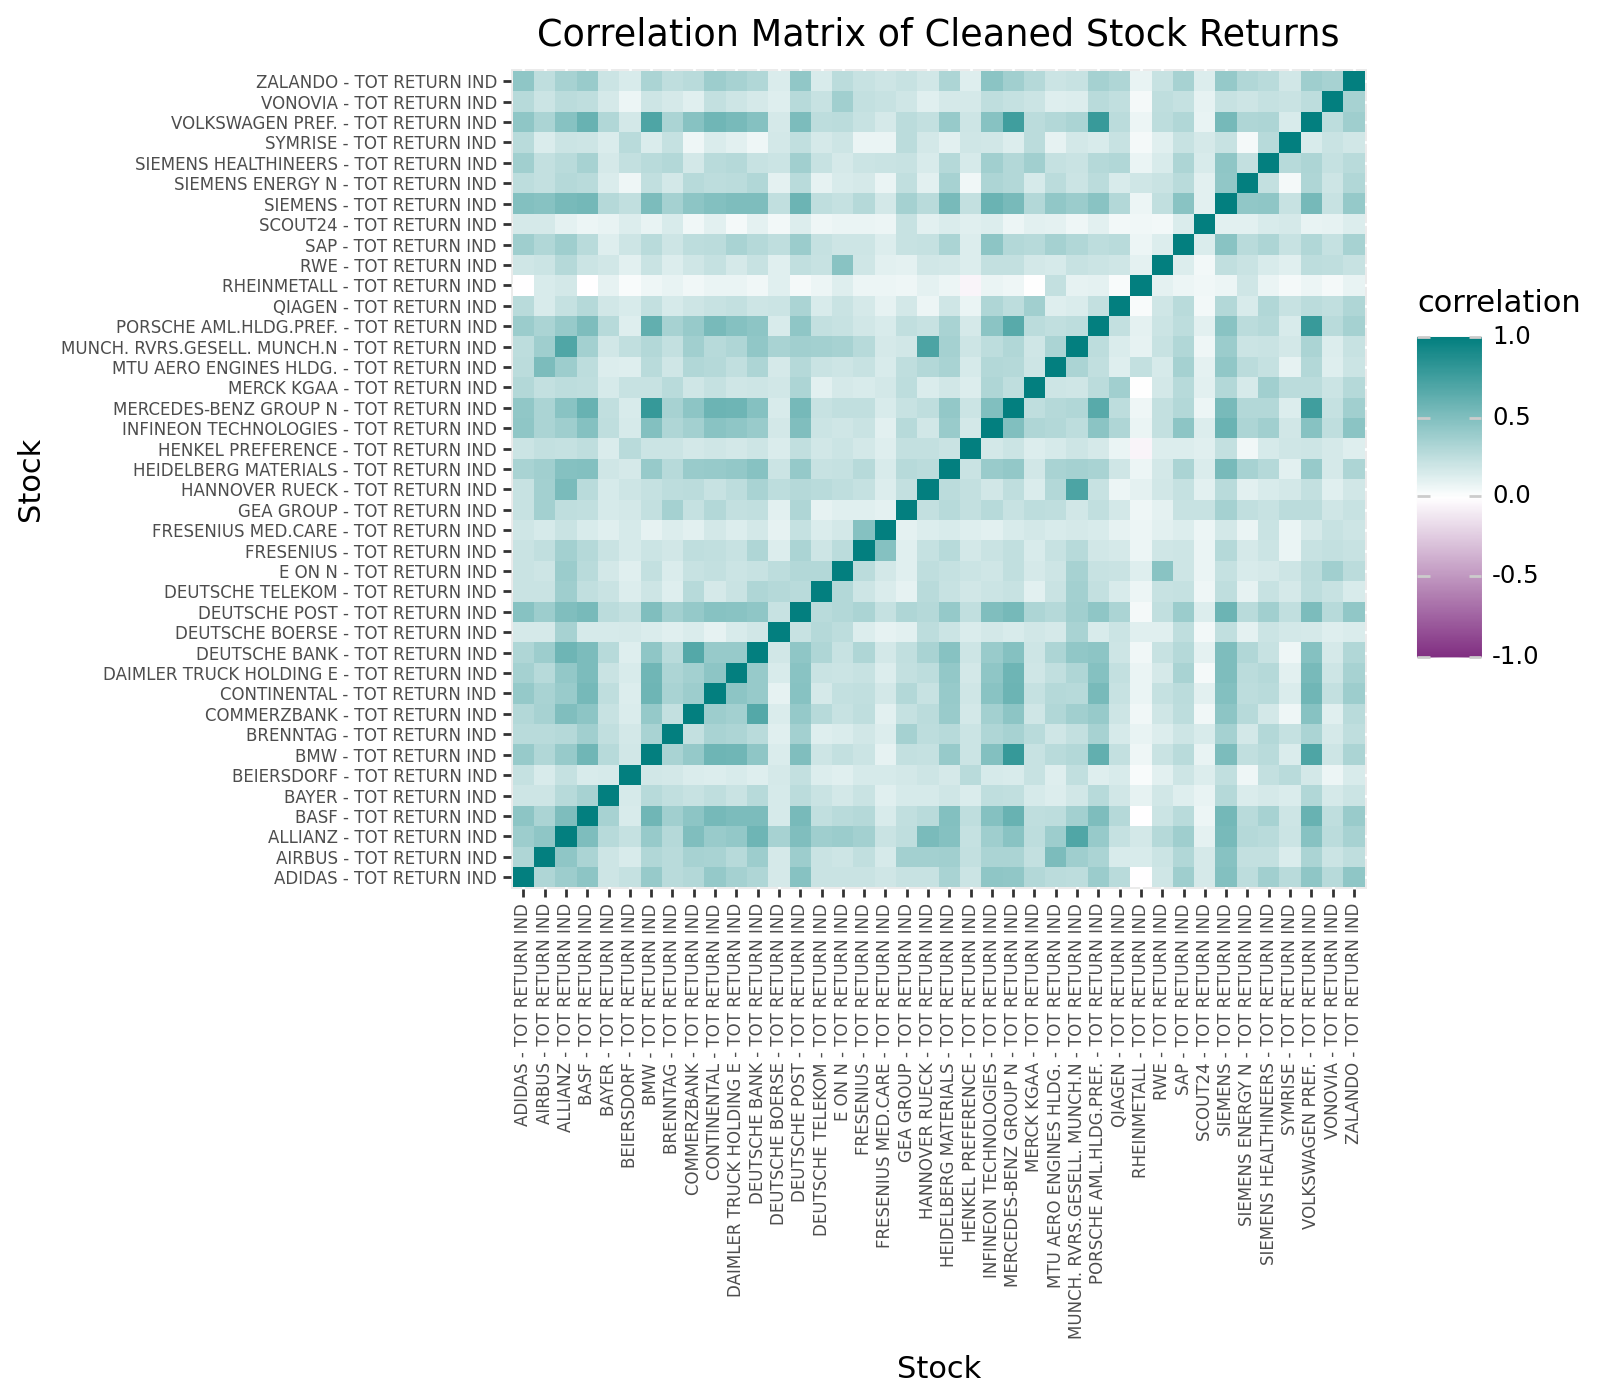

In [28]:
# Correlation matrix

correlation_plot_data = (
    correlation_matrix
    .reset_index()
    .melt(
        id_vars="index",
        var_name="stock_2",
        value_name="correlation",
    )
    .rename(columns={"index": "stock_1"})
)

correlation_plot = (
    ggplot(
        correlation_plot_data,
        aes(x="stock_1", 
            y="stock_2",
            fill="correlation"
        )
    )
    + geom_tile()
    + scale_fill_gradient2(
        low="#802E81E9",
        mid="#FFFFFF",
        high="#037F7F",
        midpoint=0,
        limits=(-1, 1),
        breaks=[-1, -0.5, 0, 0.5, 1]
    )
    + labs(
        title="Correlation Matrix of Cleaned Stock Returns",
        x="Stock",
        y="Stock"
    ) 
    + theme (
        figure_size=(8,7),
        axis_text_x=element_text(rotation = 90, size = 6),
        axis_text_y=element_text(size=6)
    )
)
correlation_plot.show()

The correlation heatmap shows mostly positive correlations between the stocks.  
This is economically plausible because all stocks belong to the German equity market and are exposed to common market factors.

## Task 7.3 Global Minimum-Variance Portfolio Weights
This task requires to compute the global MVP weights using the previously estimated covariance matrix Σ from Task 7.2.
The MVP represents the portfolio with the lowest achievable volatility within the 40-stock universe.


TASK 7.3: FULL-UNIVERSE MVP WEIGHTS


,mvp_weight,weight_percent
DEUTSCHE TELEKOM - TOT RETURN IND,0.1543,15.4292
HENKEL PREFERENCE - TOT RETURN IND,0.1222,12.2177
BEIERSDORF - TOT RETURN IND,0.1125,11.2476
QIAGEN - TOT RETURN IND,0.1068,10.6760
SCOUT24 - TOT RETURN IND,0.0951,9.5071
DEUTSCHE BOERSE - TOT RETURN IND,0.0866,8.6628
GEA GROUP - TOT RETURN IND,0.0791,7.9138
ALLIANZ - TOT RETURN IND,0.0766,7.6561
RWE - TOT RETURN IND,0.0601,6.0114
SAP - TOT RETURN IND,0.0575,5.7545



TASK 7.3: FULL-UNIVERSE MVP SUMMARY


,metric,value
0,Expected annual return,0.1081
1,Annual volatility,0.1019
2,Sharpe ratio,0.8640
3,Sum of weights,1.0000
4,Minimum weight,-0.0405
5,Maximum weight,0.1543
6,Number of negative weights,13.0000
7,Number of positive weights,27.0000


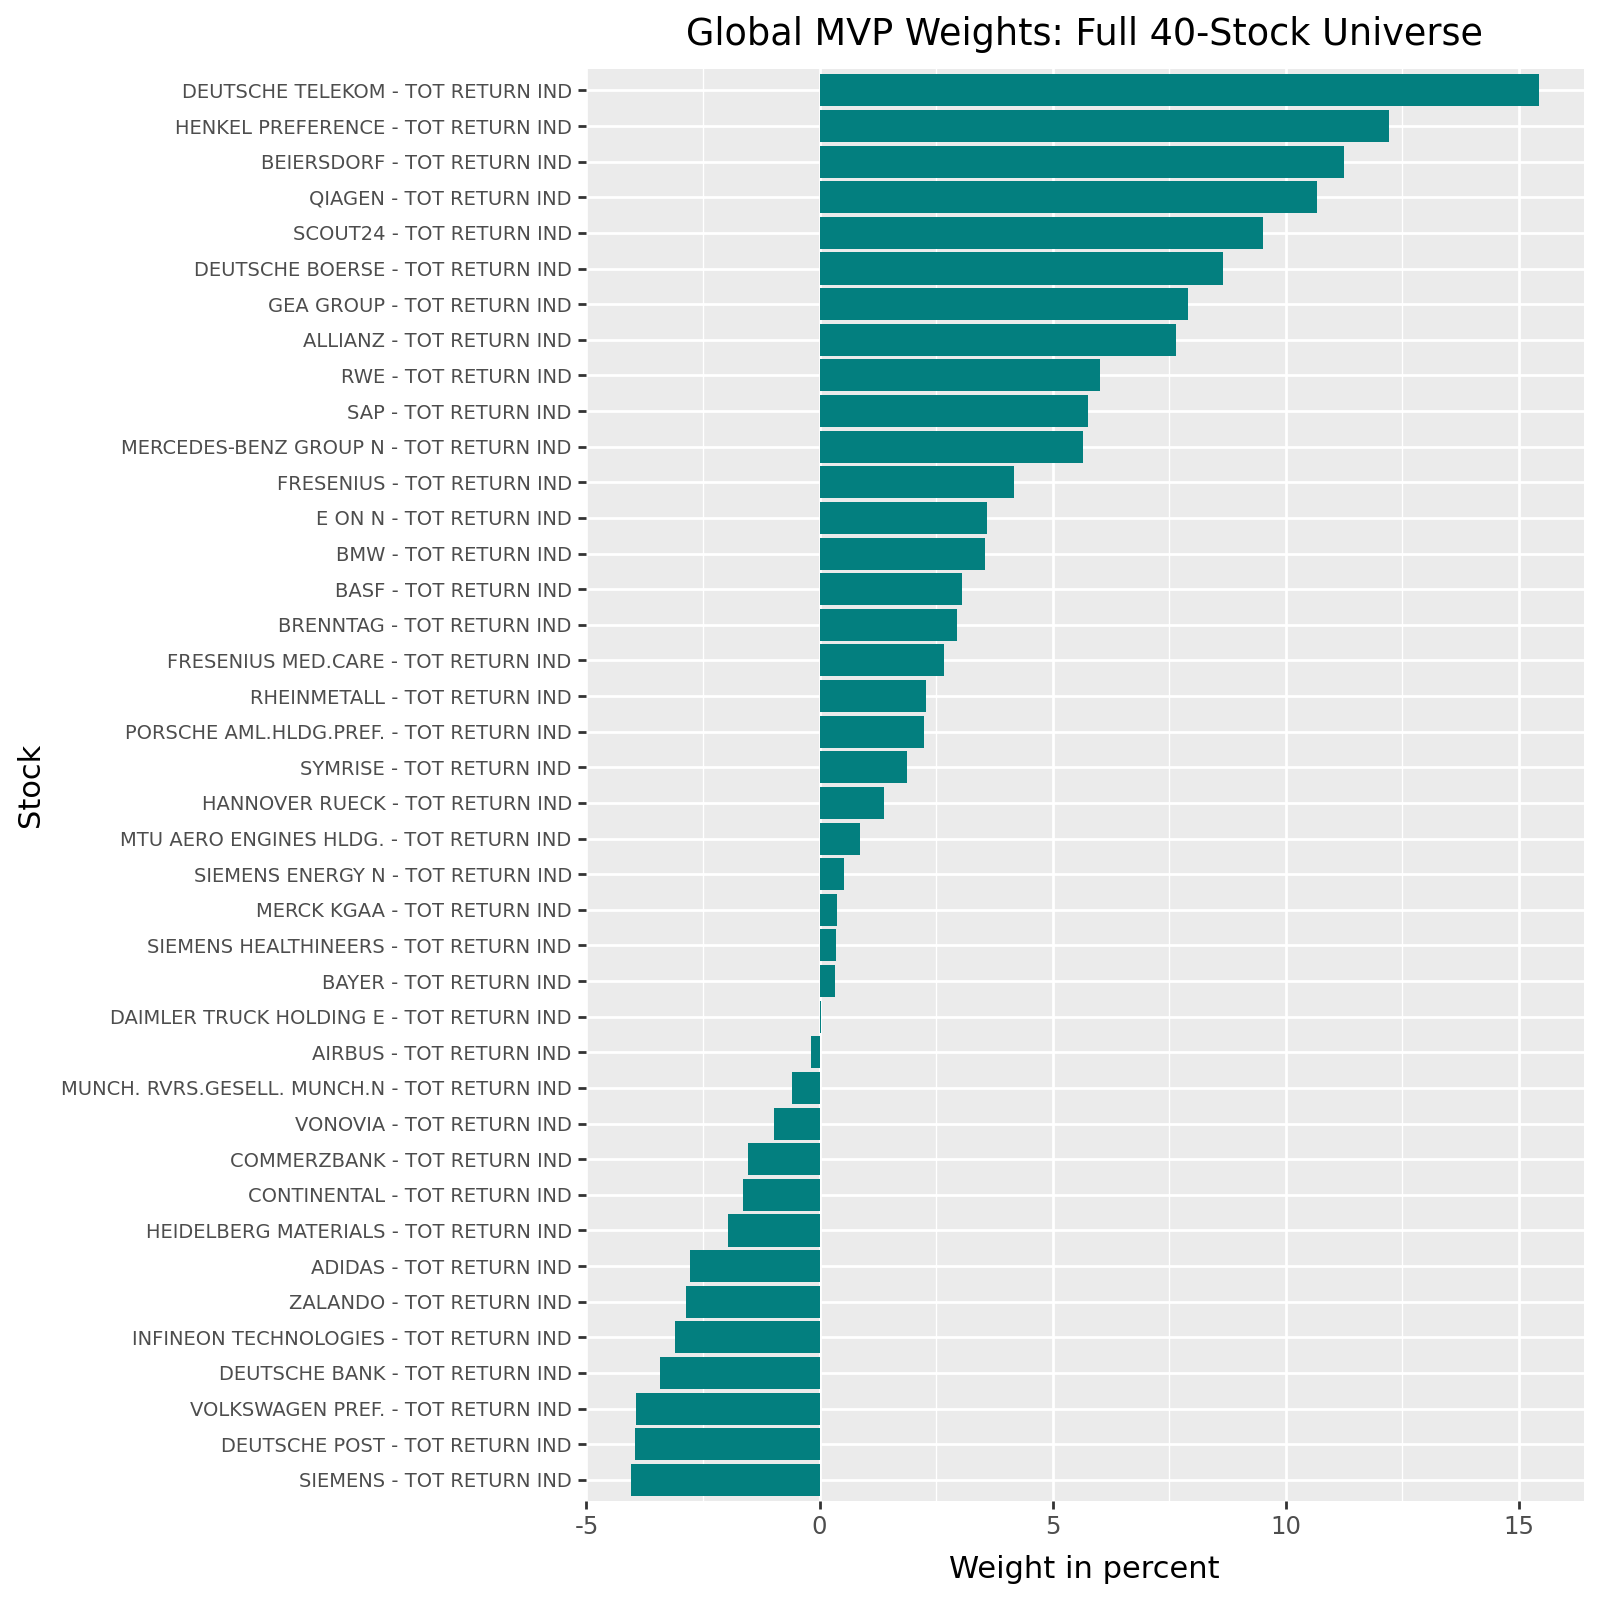

In [29]:
mvp_weights_full = compute_gmvp_weights(covariance_matrix_annual)

mvp_return_full, mvp_vol_full, mvp_sharpe_full = portfolio_performance(
    mvp_weights_full,
    mean_returns_annual,
    covariance_matrix_annual,
)

mvp_weights_full_table = (
    mvp_weights_full
    .to_frame(name="mvp_weight")
    .assign(weight_percent=lambda dataframe: 100 * dataframe["mvp_weight"])
    .sort_values("mvp_weight", ascending=False)
)

print("\nTASK 7.3: FULL-UNIVERSE MVP WEIGHTS")
display(mvp_weights_full_table.round(4))

mvp_full_summary = pd.DataFrame(
    {
        "metric": [
            "Expected annual return",
            "Annual volatility",
            "Sharpe ratio",
            "Sum of weights",
            "Minimum weight",
            "Maximum weight",
            "Number of negative weights",
            "Number of positive weights",
        ],
        "value": [
            mvp_return_full,
            mvp_vol_full,
            mvp_sharpe_full,
            mvp_weights_full.sum(),
            mvp_weights_full.min(),
            mvp_weights_full.max(),
            int((mvp_weights_full < 0).sum()),
            int((mvp_weights_full > 0).sum()),
        ],
    }
)

print("\nTASK 7.3: FULL-UNIVERSE MVP SUMMARY")
display(mvp_full_summary.round(4))

mvp_plot_data = (
    mvp_weights_full_table
    .reset_index()
)

mvp_plot_data.columns = [
    "stock",
    "mvp_weight",
    "weight_percent"
]

mvp_plot_data = mvp_plot_data.sort_values("weight_percent")

mvp_plot_data["stock"] = pd.Categorical(
    mvp_plot_data["stock"],
    categories=mvp_plot_data["stock"],
    ordered=True
)

mvp_weight_plot = (
    ggplot(
        mvp_plot_data,
        aes(
            x="stock",
            y="weight_percent"
        )   
    )
    + geom_col(fill="#037F7F")
    + coord_flip()
    + labs(
        title="Global MVP Weights: Full 40-Stock Universe",
        x="Stock",
        y="Weight in percent",
    )
    + theme(
        figure_size=(8, 8),
        axis_text_y=element_text(size=7),
    )
)

mvp_weight_plot.show()


The global MVP achieves an expected annual return of 10.81% with an annualized volatility of 10.19% which leads to a Sharpe ratio of 0.864.  
The sum of portfolio weights equals one, which confirms that the portfolio is fully invested.  
The MVP contains both short and long positions. The exploition of covariance relationships between stocks can reduce overall portfolio risk.  
The weight distribution is relatively diversified. Although some stocks have higher weights than others, the portfolio is not dominated by a single position.  

## Task 7.4: Capital Market Line and Efficient Frontier
This task extends the MVP analysis by including expected returns.  
The efficient frontier shows the best risk and return combinations in the 40 stock universe.  
The CML combines the risk-free asset with the tangency portfolio.  

Assumptions for Task 7.4:

1. The constant annual risk-free rate is 2%.

2. The 40 stocks make up the full tradeable stock universe.

3. Historical mean returns estimate the expected returns, and the historical covariance matrix estimates the future risk and co-movement.

4. Investors make decisions solely based on expected return and volatility.

5. There are no short-selling constraints, which means that negative portfolio weights may occur.

6. There are no transaction costs, taxes, liquidity restrictions, or preferences for specific firms.



In [30]:
# Tangency portfolio

tangency_weights = compute_tangency_weights(
    mean_returns_annual,
    covariance_matrix_annual,
)

tangency_return, tangency_vol, tangency_sharpe = portfolio_performance(
    tangency_weights,
    mean_returns_annual,
    covariance_matrix_annual,
)

tangency_table = (
    tangency_weights
    .to_frame(name="tangency_weight")
    .assign(
        weight_percent=lambda dataframe: (
            100 * dataframe["tangency_weight"]
        )
    )
    .sort_values("tangency_weight", ascending=False)
)

tangency_summary = pd.DataFrame(
    {
        "metric": [
            "Expected annual return",
            "Annual volatility",
            "Sharpe ratio",
            "Sum of weights",
            "Minimum weight",
            "Maximum weight",
        ],
        "value": [
            tangency_return,
            tangency_vol,
            tangency_sharpe,
            tangency_weights.sum(),
            tangency_weights.min(),
            tangency_weights.max(),
        ],
    }
)

print("\nTASK 7.4: TANGENCY PORTFOLIO SUMMARY")
display(tangency_summary.round(4))

print("\nTASK 7.4: TANGENCY PORTFOLIO WEIGHTS")
display(tangency_table.round(4))


TASK 7.4: TANGENCY PORTFOLIO SUMMARY


,metric,value
0,Expected annual return,1.1600
1,Annual volatility,0.3667
2,Sharpe ratio,3.1086
3,Sum of weights,1.0000
4,Minimum weight,-0.4439
5,Maximum weight,0.4517



TASK 7.4: TANGENCY PORTFOLIO WEIGHTS


,tangency_weight,weight_percent
RHEINMETALL - TOT RETURN IND,0.4517,45.1670
DEUTSCHE TELEKOM - TOT RETURN IND,0.3754,37.5439
HEIDELBERG MATERIALS - TOT RETURN IND,0.3116,31.1647
BMW - TOT RETURN IND,0.3111,31.1141
COMMERZBANK - TOT RETURN IND,0.3009,30.0895
MUNCH. RVRS.GESELL. MUNCH.N - TOT RETURN IND,0.2581,25.8100
SAP - TOT RETURN IND,0.2450,24.4957
SCOUT24 - TOT RETURN IND,0.2024,20.2388
SIEMENS ENERGY N - TOT RETURN IND,0.1427,14.2683
E ON N - TOT RETURN IND,0.1348,13.4777


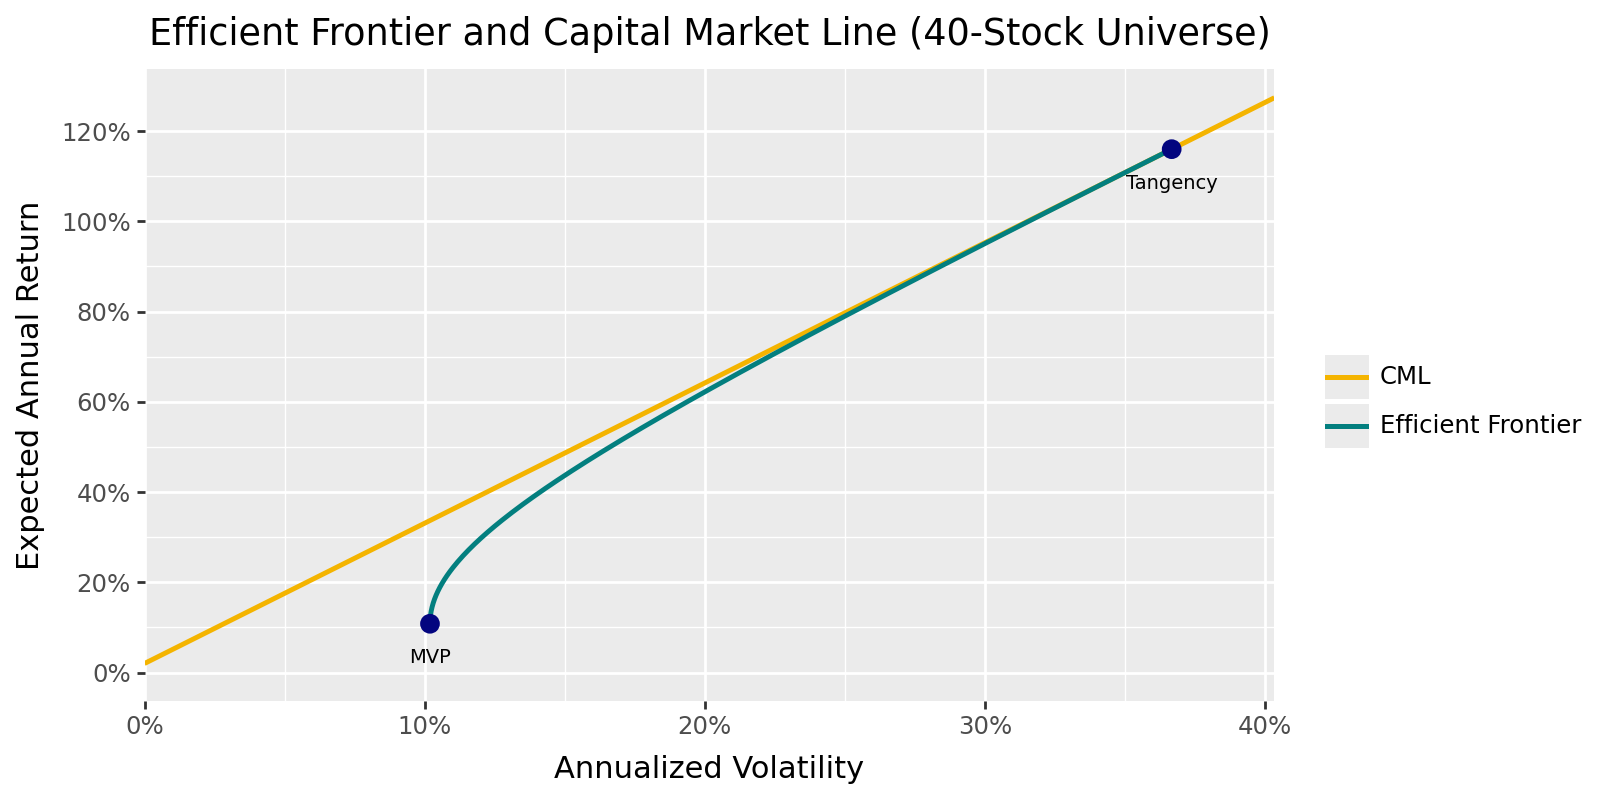

In [31]:
# Efficient frontier and CML

frontier = compute_efficient_frontier(
    mean_returns=mean_returns_annual,
    covariance_matrix=covariance_matrix_annual,
    number_points=300,
    maximum_target_return=tangency_return
)

frontier_plot_data = (
    frontier.rename(
        columns={
            "portfolio_volatility": "volatility",
            "portfolio_return": "return"
        }
    )[["volatility", "return"]]
    .loc[lambda df: df["return"] >= mvp_return_full]
)

frontier_plot_data = (
    pd.concat(
        [
            frontier_plot_data,
            pd.DataFrame({"volatility": [tangency_vol], 
                          "return": [tangency_return]})
        ],
        ignore_index=True,
    )
    .sort_values("volatility")
    .reset_index(drop=True)
)

special_points = pd.DataFrame(
    {
        "portfolio": [
            "MVP",
            "Tangency",
        ],
        "volatility": [
            mvp_vol_full,
            tangency_vol,
        ],
        "return": [
            mvp_return_full,
            tangency_return,
        ],
    }
)

cml_volatility = np.linspace(
    0,
    max(frontier_plot_data["volatility"].max(), tangency_vol) * 1.1,
    200,
)

cml_return = (
    RISK_FREE_RATE
    + (
        (tangency_return - RISK_FREE_RATE)
        / tangency_vol
    )
    * cml_volatility
)

cml_plot_data = pd.DataFrame(
    {
        "volatility": cml_volatility,
        "return": cml_return,
    }
)

frontier_plot_data["curve"] = "Efficient Frontier"
cml_plot_data["curve"] = "CML"

efficient_frontier_plot = (
    ggplot()
    + geom_line(
        cml_plot_data,
        aes(
            x="volatility",
            y="return",
            color="curve"
        ),
        size=1
    )
    + geom_line(
        frontier_plot_data,
        aes(
            x="volatility",
            y="return",
            color="curve"
        ),
        size=1
    )
    + geom_point(
        special_points,
        aes(
            x="volatility",
            y="return"
        ),
        color="#03057F",
        size=3
    )
    + geom_text(
        special_points,
        aes(
            x="volatility",
            y="return",
            label="portfolio"
        ),
        nudge_y=-0.075,
        size=7
    )
    + scale_color_manual(
        values={
            "Efficient Frontier": "#037F7F",
            "CML": "#F4B400"
        }
    )
    + scale_x_continuous(
        limits=(0, None),
        breaks=np.linspace(0, 0.4, 5),
        labels=lambda x: [f"{v:.0%}" for v in x],
        expand=(0, 0)
    )
    + scale_y_continuous(
        limits=(0, None),
         breaks=np.linspace(0, 1.2, 7),
        labels=lambda y: [f"{v:.0%}" for v in y]
    )
    + labs(
        title="Efficient Frontier and Capital Market Line (40-Stock Universe)",
        x="Annualized Volatility",
        y="Expected Annual Return",
        color=""
    )
    + theme(figure_size=(8, 4))
)

efficient_frontier_plot.show()

The CML starts at the risk-free rate of 2%. The Sharpe ratio is the slope of the CML, which measures the excess return per unit of risk.

The efficient frontier illustrates the set of optimal risky portfolios that maximize expected return for a given level of risk.   
The MVP is the lowest risk portfolio on the efficient frontier. It is located at 10.19% annual volatility and 10.81% expected annual return, as calculated in Task 7.3.  

The tangency portfolio is the portfolio with the highest Sharpe ratio and is the point where the CML touches the efficient frontier.  
In this sample, it has an annual volatility of 36.7% and an expected annual return of 116.1%.

The exceptionally high expected return of the tangency portfolio should be interpreted with caution.   
It is not a realistic forecast, but an optimization result based on historical mean returns, the historical covariance matrix, and unconstrained long-short positions.  
Therefore, the result mainly illustrates the sensitivity of mean-variance optimization to historical return estimates.

## Task 7.5: Reduced Five-Stock Universe
In this task, the analysis with efficient frontier and CML from Task 7.4 is repeated for a reduced universe of five selected stocks.  
The purpose is to compare how the efficient frontier, CML, MVP, and tangency portfolio change when the investment universe is restricted.

The five selected stocks are Allianz, Deutsche Telekom, E.ON, SAP, and Siemens.  
They represent different sectors in the order: insurance, telecommunications, utilities, technology, and industrials.  

The goal is not to choose the best-performing stocks, but to create a smaller stock universe that is economically diversified.  
The stocks are chosen based on sector representation and economic relevance.  
This makes the reduced universe suitable for comparing how a smaller investment universe changes the efficient frontier, CML, MVP, and tangency portfolio relative to the full 40-stock universe.

In [32]:

# MVP, tangency portfolio, efficient frontier and CML

selected_five_stocks = [
    "ALLIANZ - TOT RETURN IND",
    "DEUTSCHE TELEKOM - TOT RETURN IND",
    "E ON N - TOT RETURN IND",
    "SAP - TOT RETURN IND",
    "SIEMENS - TOT RETURN IND",
]

missing_selected_stocks = [
    stock for stock in selected_five_stocks
    if stock not in simple_returns_for_task_7.columns
]

if missing_selected_stocks:
    raise ValueError(
        "Some selected stocks are missing from the dataset: "
        f"{missing_selected_stocks}"
    )
# stops the code if one of the selected stocks was not found

returns_five = simple_returns_for_task_7[selected_five_stocks]

mean_returns_five_annual = returns_five.mean() * TRADING_DAYS_PER_YEAR
covariance_five_annual = returns_five.cov() * TRADING_DAYS_PER_YEAR

mvp_weights_five = compute_gmvp_weights(covariance_five_annual)

mvp_return_five, mvp_vol_five, mvp_sharpe_five = portfolio_performance(
    mvp_weights_five,
    mean_returns_five_annual,
    covariance_five_annual,
)

mvp_weights_five_table = (
    mvp_weights_five
    .to_frame(name="mvp_weight")
    .assign(weight_percent=lambda dataframe: 100 * dataframe["mvp_weight"])
    .sort_values("mvp_weight", ascending=False)
)

mvp_weights_five_table.loc["Sum of weights"] = [1.0, 100.0]

print("\nTASK 7.5: FIVE-STOCK MVP WEIGHTS")
display(mvp_weights_five_table.round(4))

tangency_weights_five = compute_tangency_weights(
    mean_returns_five_annual,
    covariance_five_annual,
)

tangency_return_five, tangency_vol_five, tangency_sharpe_five = (
    portfolio_performance(
        tangency_weights_five,
        mean_returns_five_annual,
        covariance_five_annual,
    )
)

tangency_table_five = (
    tangency_weights_five
    .to_frame(name="tangency_weight")
    .assign(
        weight_percent=lambda dataframe: (
            100 * dataframe["tangency_weight"]
        )
    )
    .sort_values("tangency_weight", ascending=False)
)

tangency_summary_five = pd.DataFrame(
    {
        "metric": [
            "Expected annual return",
            "Annual volatility",
            "Sharpe ratio",
            "Sum of weights",
            "Minimum weight",
            "Maximum weight",
        ],
        "value": [
            tangency_return_five,
            tangency_vol_five,
            tangency_sharpe_five,
            tangency_weights_five.sum(),
            tangency_weights_five.min(),
            tangency_weights_five.max(),
        ],
    }
)

print("\nTASK 7.5: FIVE-STOCK TANGENCY PORTFOLIO SUMMARY")
display(tangency_summary_five.round(4))

print("\nTASK 7.5: FIVE-STOCK TANGENCY PORTFOLIO WEIGHTS")
display(tangency_table_five.round(4))

frontier_five = compute_efficient_frontier(
    mean_returns=mean_returns_five_annual,
    covariance_matrix=covariance_five_annual,
    number_points=300,
)

frontier_five_plot_data = pd.DataFrame(
    frontier_five.rename(
        columns={
            "portfolio_volatility": "volatility",
            "portfolio_return": "return",
        }
    )[["volatility", "return"]]
)

frontier_five_plot_data = (
    frontier_five_plot_data[
        frontier_five_plot_data["return"] >= mvp_return_five
    ]
    .sort_values("volatility")
    .reset_index(drop=True)
)

tangency_five_row = pd.DataFrame(
    {
        "volatility": [tangency_vol_five],
        "return": [tangency_return_five],
    }
)

frontier_five_plot_data = (
    pd.concat(
        [
            frontier_five_plot_data,
            tangency_five_row,
        ],
        ignore_index=True,
    )
    .sort_values("volatility")
    .reset_index(drop=True)
)

special_points_five = pd.DataFrame(
    {
        "portfolio": [
            "MVP",
            "Tangency",
        ],
        "volatility": [
            mvp_vol_five,
            tangency_vol_five,
        ],
        "return": [
            mvp_return_five,
            tangency_return_five,
        ],
    }
)

cml_five_volatility = np.linspace(
    0,
    max(frontier_five_plot_data["volatility"].max(), tangency_vol_five)
    * 1.1,
    200,
)

cml_five_return = (
        RISK_FREE_RATE
        + (
            (tangency_return_five - RISK_FREE_RATE)
            / tangency_vol_five
        )
        * cml_five_volatility
)

cml_five_plot_data = pd.DataFrame(
    {
        "volatility": cml_five_volatility,
        "return": cml_five_return,
    }
)


TASK 7.5: FIVE-STOCK MVP WEIGHTS


,mvp_weight,weight_percent
DEUTSCHE TELEKOM - TOT RETURN IND,0.3714,37.1440
ALLIANZ - TOT RETURN IND,0.2547,25.4740
E ON N - TOT RETURN IND,0.2252,22.5166
SAP - TOT RETURN IND,0.1512,15.1158
SIEMENS - TOT RETURN IND,-0.0025,-0.2504
Sum of weights,1.0000,100.0000



TASK 7.5: FIVE-STOCK TANGENCY PORTFOLIO SUMMARY


,metric,value
0,Expected annual return,0.2057
1,Annual volatility,0.1503
2,Sharpe ratio,1.2359
3,Sum of weights,1.0000
4,Minimum weight,-0.0804
5,Maximum weight,0.5389



TASK 7.5: FIVE-STOCK TANGENCY PORTFOLIO WEIGHTS


,tangency_weight,weight_percent
ALLIANZ - TOT RETURN IND,0.5389,53.8877
DEUTSCHE TELEKOM - TOT RETURN IND,0.3455,34.5467
SAP - TOT RETURN IND,0.1358,13.5798
E ON N - TOT RETURN IND,0.0602,6.0244
SIEMENS - TOT RETURN IND,-0.0804,-8.0386



TASK 7.5: FULL UNIVERSE VERSUS FIVE-STOCK UNIVERSE


,universe,mvp_return,mvp_volatility,mvp_sharpe,tangency_return,tangency_volatility,tangency_sharpe
0,Full 40-stock universe,0.1081,0.1019,0.8640,1.1600,0.3667,3.1086
1,Reduced five-stock universe,0.1878,0.1428,1.1746,0.2057,0.1503,1.2359


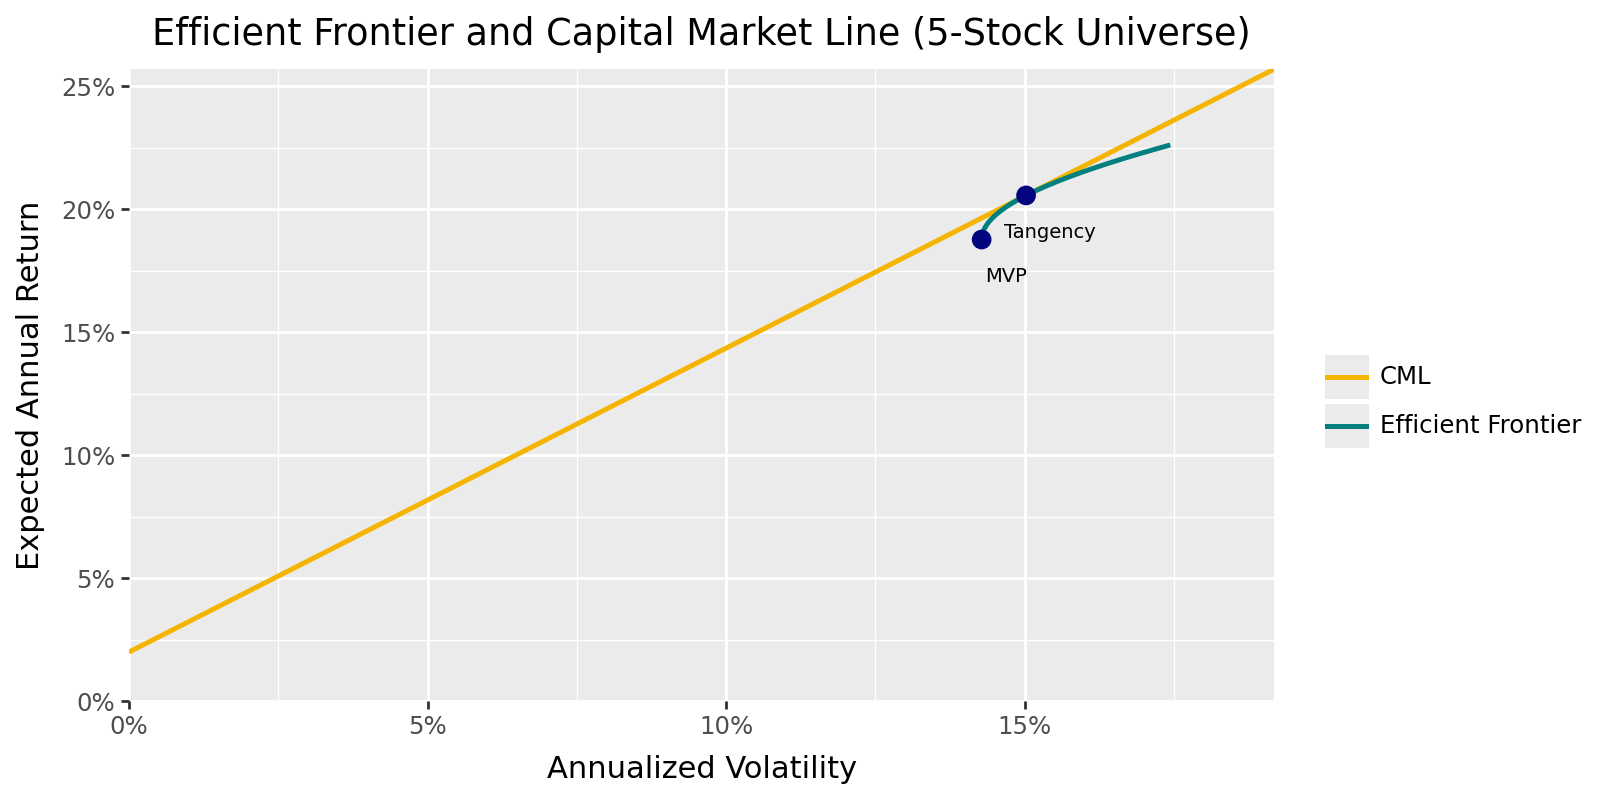

In [33]:
# Comparison between the full universe and the five stock universe

comparison_task_74_vs_75 = pd.DataFrame(
    {
        "universe": [
            "Full 40-stock universe",
            "Reduced five-stock universe",
        ],
        "mvp_return": [
            mvp_return_full,
            mvp_return_five,
        ],
        "mvp_volatility": [
            mvp_vol_full,
            mvp_vol_five,
        ],
        "mvp_sharpe": [
            mvp_sharpe_full,
            mvp_sharpe_five,
        ],
        "tangency_return": [
            tangency_return,
            tangency_return_five,
        ],
        "tangency_volatility": [
            tangency_vol,
            tangency_vol_five,
        ],
        "tangency_sharpe": [
            tangency_sharpe,
            tangency_sharpe_five,
        ],
    }
)

print("\nTASK 7.5: FULL UNIVERSE VERSUS FIVE-STOCK UNIVERSE")
display(comparison_task_74_vs_75.round(4))

# Efficient frontier and capital market line for five stock universe

frontier_five_plot_data["curve"] = "Efficient Frontier"
cml_five_plot_data["curve"] = "CML"

efficient_frontier_five_plot = (
    ggplot()
    + geom_line(
        cml_five_plot_data,
        aes(
            x="volatility",
            y="return",
            color="curve"
        ),
        size=1,
    )
    + geom_line(
        frontier_five_plot_data,
        aes(
            x="volatility",
            y="return",
            color="curve"
        ),
        size=1,
    )
    + geom_point(
        special_points_five,
        aes(
            x="volatility",
            y="return"
        ),
        color="#03057F",
        size=3,
    )
    + geom_text(
        special_points_five,
        aes(
            x="volatility", 
            y="return", 
            label="portfolio"
	    ),
        nudge_y=-0.015,
        nudge_x=0.004,
        size=7,
    )
    + scale_color_manual(
        values={
            "Efficient Frontier": "#037F7F",
            "CML": "#F4B400"
        }
    )
    + scale_x_continuous(
        limits=(0, None),
        breaks=np.linspace(0, 0.2, 5),
        labels=lambda x: [f"{v:.0%}" for v in x],
        expand=(0, 0)
    )
    + scale_y_continuous(
        limits=(0, None),
         breaks=np.linspace(0, 0.3, 7),
        labels=lambda y: [f"{v:.0%}" for v in y],
        expand=(0, 0)
    )
    + labs(
        title="Efficient Frontier and Capital Market Line (5-Stock Universe)",
        x="Annualized Volatility",
        y="Expected Annual Return",
        color=""
    )
    + theme(figure_size=(8, 4))
)

efficient_frontier_five_plot.show()

The five-stock MVP is located at an annual volatility of 14.28% and an expected annual return of 18.78%.
The five-stock tangency portfolio is located at an annual volatility of 15.03% and an expected annual return of 20.57%. 

Compared with the full 40-stock universe, the difference between the MVP and tangency portfolio is much smaller.  
This indicates that the reduced universe offers fewer opportunities to improve the risk-return trade-off through diversification.  

The efficient frontier is substantially shorter and flatter than in the full-universe case.  
This suggests, that investors have access to a narrower set of attainable risk-return combinations.  
This is reasonable because there are only five stocks available and therefore there are not as many covariance relationships as in the larger universe.

Comparing Task 7.4 and Task 7.5 highlights the importance of the investment universe.  
Technically, the full 40-stock universe uses a much larger covariance matrix and therefore contains many more variance and covariance relationships than the reduced five-stock universe.  
This gives the optimizer more possibilities to combine assets in a way that reduces portfolio risk or improves the risk-return trade-off.  

Economically, the full universe provides stronger diversification opportunities.  
This is visible in the lower MVP volatility of the 40-stock universe compared with the five-stock universe.  
The full universe also produces a broader efficient frontier and a steeper CML in this historical sample.  

However, the CML comparison should be interpreted carefully because the tangency portfolio depends strongly on historical mean returns and unconstrained long-short optimization.  
Therefore, the steeper CML in the full-universe case should not be interpreted as a guaranteed opportunity to achieve much higher future returns.  
Instead, it shows that, within this historical sample and under the assumptions of mean-variance optimization, the larger investment universe offers more attractive attainable risk-return combinations.

## Task 7.6 Rolling Backtest
This task evaluates whether the MVP performs well out of sample compared with a naive equally weighted portfolio.  
The MVP weights are estimated using rolling windows of 100 observations.  
Each estimation window is followed by an evaluation window of 25 trading days.  
The window is then shifted forward by 25 trading days.

In [34]:
# Rolling backtest and statistical tests

backtest_results, out_of_sample_daily_returns = run_rolling_backtest(
    simple_returns_for_task_7
)

backtest_results = backtest_results.set_index("window")

print("\nTASK 7.6: ROLLING BACKTEST RESULTS")
display(backtest_results.round(4))

mvp_in_out_vol_test = paired_difference_test(
    backtest_results["mvp_vol_in"],
    backtest_results["mvp_vol_out"],
    alternative="two-sided",
)

naive_minus_mvp_oos_vol_test = paired_difference_test(
    backtest_results["naive_vol_out"],
    backtest_results["mvp_vol_out"],
    alternative="greater",
)

mvp_minus_naive_oos_sharpe_test = paired_difference_test(
    backtest_results["mvp_sharpe_out"],
    backtest_results["naive_sharpe_out"],
    alternative="greater",
)

test_results = pd.DataFrame(
    [
        {
            "question": (
                "MVP in-sample volatility differs from "
                "MVP out-of-sample volatility"
            ),
            "mean_difference": (
                mvp_in_out_vol_test["mean_difference"]
            ),
            "t_statistic": mvp_in_out_vol_test["t_statistic"],
            "p_value": mvp_in_out_vol_test["p_value"],
            "alternative": "two-sided",
            "observations": mvp_in_out_vol_test["observations"],
        },
        {
            "question": (
                "Naive out-of-sample volatility is higher than "
                "MVP out-of-sample volatility"
            ),
            "mean_difference": (
                naive_minus_mvp_oos_vol_test["mean_difference"]
            ),
            "t_statistic": naive_minus_mvp_oos_vol_test["t_statistic"],
            "p_value": naive_minus_mvp_oos_vol_test["p_value"],
            "alternative": "greater",
            "observations": naive_minus_mvp_oos_vol_test["observations"],
        },
        {
            "question": (
                "MVP out-of-sample Sharpe ratio is higher than "
                "naive out-of-sample Sharpe ratio"
            ),
            "mean_difference": (
                mvp_minus_naive_oos_sharpe_test["mean_difference"]
            ),
            "t_statistic": mvp_minus_naive_oos_sharpe_test["t_statistic"],
            "p_value": mvp_minus_naive_oos_sharpe_test["p_value"],
            "alternative": "greater",
            "observations": (
                mvp_minus_naive_oos_sharpe_test["observations"]
            ),
        },
    ]
)

print("\nTASK 7.6: STATISTICAL TEST RESULTS")
display(test_results.round(4))


TASK 7.6: ROLLING BACKTEST RESULTS


,estimation_start,estimation_end,evaluation_start,evaluation_end,mvp_return_in,mvp_vol_in,mvp_sharpe_in,naive_return_in,naive_vol_in,naive_sharpe_in,mvp_return_out,mvp_vol_out,mvp_sharpe_out,naive_return_out,naive_vol_out,naive_sharpe_out
window,,,,,,,,,,,,,,,,
1,2021-12-13,2022-05-05,2022-05-06,2022-06-09,0.2335,0.1077,1.9829,-0.1712,0.2455,-0.7789,0.1597,0.1609,0.8685,0.2557,0.1802,1.3083
2,2022-01-19,2022-06-09,2022-06-10,2022-07-14,0.2902,0.1111,2.4324,-0.1842,0.2549,-0.8011,-0.6269,0.1924,-3.3617,-1.1947,0.2440,-4.9785
3,2022-02-23,2022-07-14,2022-07-15,2022-08-18,0.4512,0.1038,4.1530,-0.3631,0.2528,-1.5158,-0.1860,0.1415,-1.4558,0.8679,0.1625,5.2189
4,2022-03-30,2022-08-18,2022-08-19,2022-09-22,0.0552,0.0866,0.4063,-0.1806,0.1949,-1.0294,-0.6792,0.1398,-5.0014,-0.9030,0.1998,-4.6196
5,2022-05-06,2022-09-22,2022-09-23,2022-10-27,0.1166,0.0859,1.1243,-0.2435,0.2030,-1.2980,-0.2732,0.1743,-1.6821,0.3415,0.2279,1.4108
6,2022-06-10,2022-10-27,2022-10-28,2022-12-01,0.1289,0.0925,1.1771,-0.2221,0.2145,-1.1284,0.2132,0.1505,1.2839,0.9890,0.1790,5.4131
7,2022-07-15,2022-12-01,2022-12-02,2023-01-06,0.1961,0.0849,2.0736,0.3239,0.1967,1.5449,-0.1628,0.1077,-1.6982,0.3574,0.1556,2.1678
8,2022-08-19,2023-01-06,2023-01-09,2023-02-10,0.0797,0.0788,0.7580,0.1962,0.1944,0.9064,0.5329,0.1335,3.8428,0.4187,0.1049,3.7994
9,2022-09-23,2023-02-10,2023-02-13,2023-03-17,0.2918,0.0706,3.8526,0.5266,0.1708,2.9655,-0.2383,0.1215,-2.1267,-0.4167,0.1591,-2.7453



TASK 7.6: STATISTICAL TEST RESULTS


,question,mean_difference,t_statistic,p_value,alternative,observations
0,MVP in-sample volatility differs from MVP out-...,-0.0503,-7.8867,0.0000,two-sided,37
1,Naive out-of-sample volatility is higher than ...,0.0109,1.8930,0.0332,greater,37
2,MVP out-of-sample Sharpe ratio is higher than ...,-0.6688,-1.1680,0.8748,greater,37


The rolling backtest result table demonstrates that portfolio performance varies considerably across time.  
Some rolling windows generate strongly positive returns, while others produce negative returns.  
Therefore, conclusions should not be drawn from a single window but from the statistical tests and the overall out-of-sample summary.

The statistical test results provide evidence for the three questions in Task 7.6.  

1. The MVP in-sample volatility differs significantly from its realized out-of-sample volatility.  
The p-value is below 0.05, so the null hypothesis of no difference is rejected.  
The mean difference is negative, which means that the realized out-of-sample volatility was higher than the in-sample volatility.  
This suggests that the MVP underestimated future risk during the rolling backtest.
2. The naive portfolio has significantly higher out-of-sample volatility than the MVP.  
The one-sided test has a p-value below 0.05, so the null hypothesis that the naive portfolio does not have higher volatility is rejected.  
This supports the main purpose of the MVP, since the minimum-variance optimization successfully reduced realized portfolio volatility.  
3. The Sharpe ratio comparison does not provide evidence that the MVP has better risk-adjusted performance than the naive portfolio.  
The p-value is 0.8748, so the null hypothesis is not rejected.  
The mean difference is negative, which indicates that the naive portfolio achieved the higher out-of-sample Sharpe ratio in this backtest.  

Overall, the MVP performs better in terms of volatility reduction, while the naive equally weighted portfolio performs better in terms of risk-adjusted performance.

In [35]:
# Overall out-of-sample performance

oos_mvp_annual_return = annualized_return(
    out_of_sample_daily_returns["mvp_daily_return"]
)
oos_naive_annual_return = annualized_return(
    out_of_sample_daily_returns["naive_daily_return"]
)

oos_mvp_annual_volatility = annualized_volatility(
    out_of_sample_daily_returns["mvp_daily_return"]
)
oos_naive_annual_volatility = annualized_volatility(
    out_of_sample_daily_returns["naive_daily_return"]
)

oos_mvp_sharpe = sharpe_ratio(
    oos_mvp_annual_return,
    oos_mvp_annual_volatility,
)
oos_naive_sharpe = sharpe_ratio(
    oos_naive_annual_return,
    oos_naive_annual_volatility,
)

oos_performance_summary = pd.DataFrame(
    {
        "strategy": [
            "MVP",
            "Naive equally weighted",
        ],
        "annualized_return": [
            oos_mvp_annual_return,
            oos_naive_annual_return,
        ],
        "annualized_volatility": [
            oos_mvp_annual_volatility,
            oos_naive_annual_volatility,
        ],
        "sharpe_ratio": [
            oos_mvp_sharpe,
            oos_naive_sharpe,
        ],
    }
)

oos_performance_summary = oos_performance_summary.set_index("strategy")

print("\nTASK 7.6: OUT-OF-SAMPLE PERFORMANCE SUMMARY")
display(oos_performance_summary.round(4))


TASK 7.6: OUT-OF-SAMPLE PERFORMANCE SUMMARY


,annualized_return,annualized_volatility,sharpe_ratio
strategy,,,
MVP,0.0856,0.1287,0.5097
Naive equally weighted,0.1569,0.1425,0.9607


This out-of-sample performance summary shows which stragey performed better overall.  
The MVP achieved lower annualized volatility (12.87%) than the naive equally weighted portfolio (14.25%). Therefore it did reduce portfolio risk sucessfully.  
However, the MVP generated substantially lower return (8.56% versus 15.69%). The naive equally weighted portfolio achieved a higher sharpe ratio (0.96 versus 0.51).  
This suggests that although the MVP reduced risk, the reduction in volatility was not sufficicent to compensate for the lower realized returns.  
Therefore, the naive equally weighted portfolio has better risk-adjusted performance during the evaluation period.

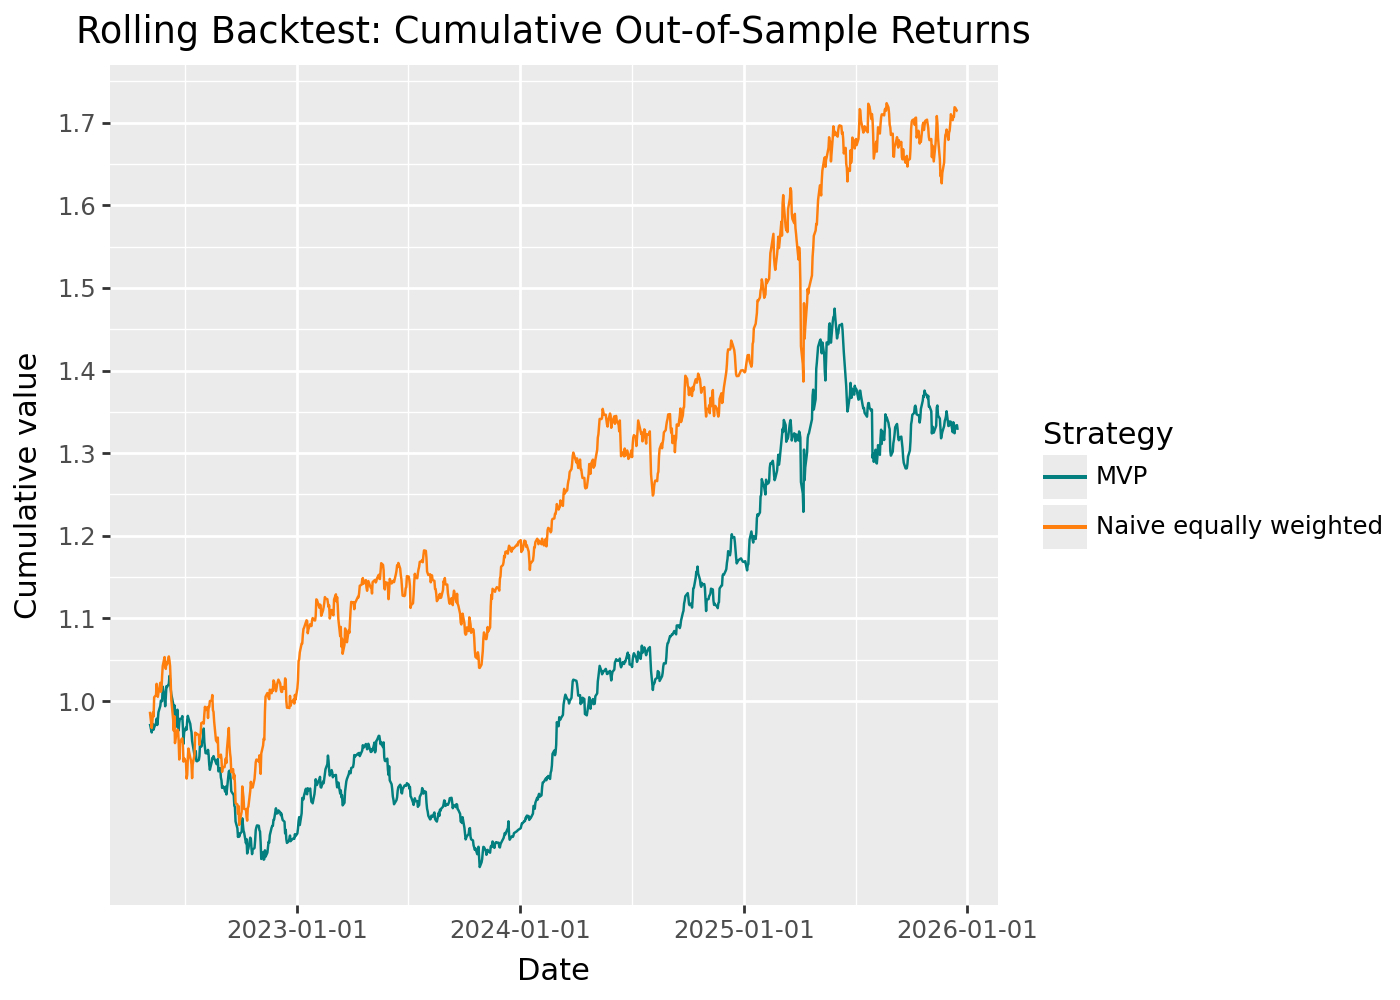

In [36]:
# Cumulative return plot

cumulative_oos_returns = (
    1 + out_of_sample_daily_returns
).cumprod()

cumulative_plot_data = (
    cumulative_oos_returns
    .reset_index()
    .rename(columns={"index": "date"})
    .melt(
        id_vars="Date",
        var_name="strategy",
        value_name="cumulative_value",
    )
)

cumulative_plot_data["strategy"] = (
    cumulative_plot_data["strategy"]
    .replace(
        {
            "mvp_daily_return": "MVP",
            "naive_daily_return": "Naive equally weighted"
        }
    )
)

cumulative_plot = (
    ggplot(
        cumulative_plot_data,
        aes(
            x="Date",
            y="cumulative_value",
            color="strategy"
        )
    )
    + geom_line(size=0.5)
    + scale_color_manual(
        values={
            "MVP": "#037F7F",
            "Naive equally weighted": "#FF7F0E"
        }
    )
    + scale_y_continuous(breaks=[1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8])
    + labs(
        title="Rolling Backtest: Cumulative Out-of-Sample Returns",
        x="Date",
        y="Cumulative value",
        color="Strategy"
    )
    + theme(figure_size=(7,5))
)

cumulative_plot.show()



The cumulative return plot shows the development of one unit invested in each strategy during the out-of-sample period.  
The cumulative value is normalized to one before the first out-of-sample return is applied.  
Both strategies generated positive cumulative performance, but the naive equally weighted portfolio ended at a higher cumulative value.  

This visual result supports the performance summary: the MVP reduced volatility, but the naive strategy achieved stronger wealth growth and a higher Sharpe ratio.
